# Adversarial Robustness for Chest X-ray Classification
### Combined notebook — Person A (dataset / fine-tuning / attacks) + Person B (defenses / comparison / demo)

Fine-tuning has been rewritten to fix the training collapse from the original
notebook (loss flat at `ln(2) = 0.693` for all 10 epochs — the model never
learned anything). Real **C&W** (`L2CarliniWagnerAttack`) and **Square Attack**
(`SquareAttack`) are implemented in place of the DeepFool placeholder and the
never-finished HopSkipJump attempt.


## Person A — Setup

In [1]:
# NOTE: opencv (cv2, used later for the CLAHE defense) wasn't in the original
# pip install line -- it only worked because something else happened to pull
# it in transitively. Added explicitly (headless build -- no GUI/X11 deps
# needed on a remote GPU box) so this doesn't silently break on environments
# where nothing else drags it in.
!pip install torchxrayvision scikit-learn foolbox gradio matplotlib seaborn kaggle opencv-python-headless -q


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Cell 2: Imports
import torch

print(torch.__version__, torch.cuda.is_available(), torch.cuda.get_device_name(0))

import torchxrayvision as xrv
import torchvision.transforms as T
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

2.11.0+cu130 True NVIDIA A100-PCIE-40GB
Device : cuda
GPU    : NVIDIA A100-PCIE-40GB


In [3]:
# JARVISLABS CONFIG: only /home persists across pause/resume -- anything
# written outside /home (which is where ~/.kaggle lands if $HOME isn't under
# /home on this container) gets wiped the next time you resume, and you'd
# have to re-upload kaggle.json every session. Keeping the Kaggle config
# under /home and pointing KAGGLE_CONFIG_DIR at it makes it durable.
import os
os.environ["KAGGLE_CONFIG_DIR"] = "/home/.kaggle"

!mkdir -p /home/.kaggle
!cp kaggle.json /home/.kaggle/
!chmod 600 /home/.kaggle/kaggle.json
!pip install kaggle --quiet

# !rm -f /home/data/Data_Entry_2017.csv  # clear any corrupted partial download

!ls /home/data
!cat /home/.kaggle/kaggle.json


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ARXIV_V5_CHESTXRAY.pdf	README_CHESTXRAY.pdf  images_005  images_010
BBox_List_2017.csv	images_001	      images_006  images_011
Data_Entry_2017.csv	images_002	      images_007  images_012
FAQ_CHESTXRAY.pdf	images_003	      images_008  test_list.txt
LOG_CHESTXRAY.pdf	images_004	      images_009  train_val_list.txt
{"username":"jayaramsomasi","key":"06f22e0a78c2e7281139446df06de045"}

In [8]:
!kaggle datasets download -d nih-chest-xrays/data -p /home/data --unzip

Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/data
License(s): CC0-1.0
100%|█████████████████████████████████████▉| 42.0G/42.0G [00:30<00:00, 1.33GB/s]
100%|██████████████████████████████████████| 42.0G/42.0G [00:30<00:00, 1.47GB/s]


In [4]:
!df -h /home
!ls -la /home/data

Filesystem      Size  Used Avail Use% Mounted on
/dev/rbd1       100G   44G   57G  44% /home
total 19308
drwxr-xr-x 15 root root    4096 Aug  7 13:52 .
drwxr-xr-x 13 root root    4096 Aug  8 04:33 ..
drwxr-xr-x  2 root root       6 Aug  7 13:05 .ipynb_checkpoints
-rw-r--r--  1 root root 8963138 Aug  7 13:51 ARXIV_V5_CHESTXRAY.pdf
-rw-r--r--  1 root root   92416 Aug  7 13:51 BBox_List_2017.csv
-rw-r--r--  1 root root 7861152 Aug  7 13:51 Data_Entry_2017.csv
-rw-r--r--  1 root root   72223 Aug  7 13:51 FAQ_CHESTXRAY.pdf
-rw-r--r--  1 root root    3919 Aug  7 13:51 LOG_CHESTXRAY.pdf
-rw-r--r--  1 root root  847223 Aug  7 13:51 README_CHESTXRAY.pdf
drwxr-xr-x  3 root root      20 Aug  7 13:51 images_001
drwxr-xr-x  3 root root      20 Aug  7 13:51 images_002
drwxr-xr-x  3 root root      20 Aug  7 13:51 images_003
drwxr-xr-x  3 root root      20 Aug  7 13:51 images_004
drwxr-xr-x  3 root root      20 Aug  7 13:51 images_005
drwxr-xr-x  3 root root      20 Aug  7 13:51 images_006
drwxr-xr-x 

In [7]:
import os, random, glob
from torch.utils.data import Subset

MERGE_DIR = "/home/working/all_images"
os.makedirs(MERGE_DIR, exist_ok=True)

folders_to_use = [
    "/home/data/images_001/images",
    "/home/data/images_002/images",
    "/home/data/images_003/images",
    "/home/data/images_004/images",
    "/home/data/images_005/images",
    "/home/data/images_006/images",
    "/home/data/images_007/images",
    "/home/data/images_008/images",
]

print("Symlinking folders...")
for folder in folders_to_use:
    if not os.path.exists(folder):
        print(f"  Skipping (not found): {folder}")
        continue
    count = 0
    for fname in os.listdir(folder):
        src = os.path.join(folder, fname)
        dst = os.path.join(MERGE_DIR, fname)
        if not os.path.exists(dst):
            os.symlink(src, dst)
            count += 1
    print(f"  Linked {count} files from {folder.split('/')[-2]}")

total_linked = len(os.listdir(MERGE_DIR))
print(f"\nTotal images in merged folder: {total_linked}")

IMG_PATH = MERGE_DIR
CSV_PATH = "/home/data/Data_Entry_2017.csv"

transform = T.Compose([
    xrv.datasets.XRayCenterCrop(),
    xrv.datasets.XRayResizer(224)
])

dataset = xrv.datasets.NIH_Dataset(
    imgpath=IMG_PATH,
    csvpath=CSV_PATH,
    transform=transform
)

available = set(os.listdir(IMG_PATH))
valid_indices = [
    i for i, fname in enumerate(dataset.csv['Image Index'].values)
    if fname in available
]
print(f"Valid matched indices: {len(valid_indices)}")

random.seed(42)
random.shuffle(valid_indices)
train_n = int(0.70 * len(valid_indices))
val_n   = int(0.15 * len(valid_indices))
test_n  = len(valid_indices) - train_n - val_n

train_ds = Subset(dataset, valid_indices[:train_n])
val_ds   = Subset(dataset, valid_indices[train_n:train_n+val_n])
test_ds  = Subset(dataset, valid_indices[train_n+val_n:])

test_loader = DataLoader(
    test_ds, batch_size=32, shuffle=False,
    num_workers=2, pin_memory=(device.type == "cuda")
)

print(f"Train : {train_n}, Val : {val_n}, Test : {test_n}")
print(f"Test loader batches : {len(test_loader)}")
print(f"Pathologies : {dataset.pathologies}")

Symlinking folders...
  Linked 0 files from images_001
  Linked 0 files from images_002
  Linked 0 files from images_003
  Linked 0 files from images_004
  Linked 0 files from images_005
  Linked 0 files from images_006
  Linked 0 files from images_007
  Linked 0 files from images_008

Total images in merged folder: 74999
Valid matched indices: 17152
Train : 12006, Val : 2572, Test : 2574
Test loader batches : 81
Pathologies : ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [8]:
# Cell 4: Load DenseNet-121 (CheXNet weights, trained on NIH data)
model = xrv.models.DenseNet(weights="densenet121-res224-nih")
model = model.to(device)
model.eval()

params = sum(p.numel() for p in model.parameters())
print(f"Model    : DenseNet-121")
print(f"Weights  : densenet121-res224-nih (CheXNet)")
print(f"Params   : {params:,}")

Model    : DenseNet-121
Weights  : densenet121-res224-nih (CheXNet)
Params   : 6,966,034


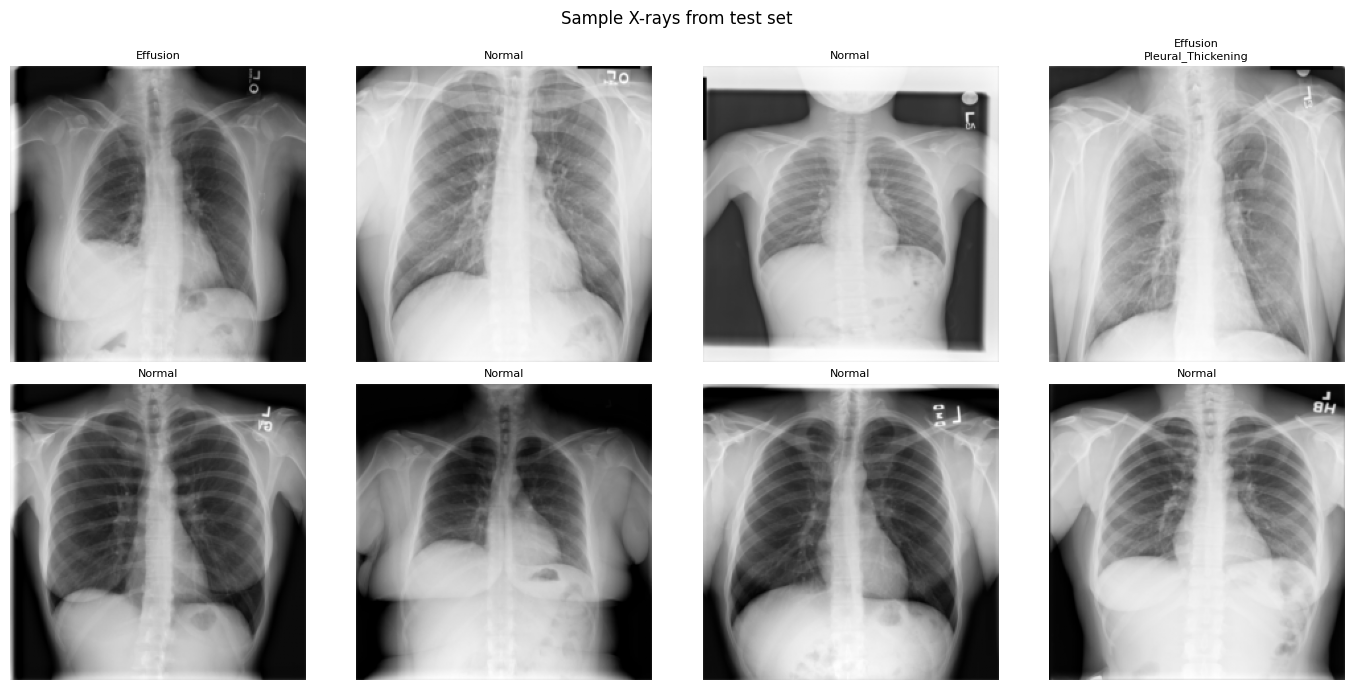

If these look like chest X-rays -- everything is working correctly.


In [9]:
# Cell 5: Sanity check
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):
    sample = test_ds[i]
    img    = np.array(sample["img"][0])
    labels = np.array(sample["lab"])
    label_names = [dataset.pathologies[j] for j, v in enumerate(labels) if v == 1]
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title("\n".join(label_names) if label_names else "Normal", fontsize=8)
    axes[i].axis("off")

plt.suptitle("Sample X-rays from test set", fontsize=12)
plt.tight_layout()
plt.savefig("sample_xrays.png", dpi=150, bbox_inches="tight")
plt.show()
print("If these look like chest X-rays -- everything is working correctly.")

In [10]:
# Cell 6: Evaluate clean accuracy -- THE BASELINE
model.eval()
all_probs  = []
all_labels = []

print("Running baseline evaluation...")
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        images = batch["img"].to(device)
        labels = batch["lab"]

        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy()

        probs_aligned = np.zeros((probs.shape[0], len(dataset.pathologies)))
        for j, pname in enumerate(dataset.pathologies):
            if pname in model.pathologies:
                model_idx = list(model.pathologies).index(pname)
                probs_aligned[:, j] = probs[:, model_idx]

        all_probs.append(probs_aligned)
        all_labels.append(labels.numpy())

        if i % 10 == 0:
            print(f"  Batch {i}/{len(test_loader)}")

all_probs  = np.concatenate(all_probs,  axis=0)
all_labels = np.concatenate(all_labels, axis=0).astype(float)
all_labels[all_labels == -1] = np.nan

print(f"Done. Evaluated {len(all_probs):,} images.")
print(f"\nProb range   : {all_probs.min():.4f} - {all_probs.max():.4f}")
print(f"% above 0.5  : {(all_probs > 0.5).mean()*100:.1f}%")

Running baseline evaluation...
  Batch 0/81
  Batch 10/81
  Batch 20/81
  Batch 30/81
  Batch 40/81
  Batch 50/81
  Batch 60/81
  Batch 70/81
  Batch 80/81
Done. Evaluated 2,574 images.

Prob range   : 0.5000 - 0.7287
% above 0.5  : 99.9%


In [11]:
# Cell 7: Full metrics -- Precision, Recall, F1, AUC per class
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score)

def compute_full_metrics(probs, labels, pathology_names, threshold=0.5):
    n_classes = len(pathology_names)

    # NEW: threshold can be a single float (old behavior) or a
    # dict {pathology_name: threshold} for per-class calibration.
    if isinstance(threshold, dict):
        thresh_arr = np.array([threshold.get(name, 0.5) for name in pathology_names])
    else:
        thresh_arr = np.full(n_classes, threshold)

    preds = (probs > thresh_arr[np.newaxis, :]).astype(int)   # broadcasts per column

    per_class = {}
    auc_list, prec_list, rec_list, f1_list = [], [], [], []
    for i, name in enumerate(pathology_names):
        l = labels[:, i].copy()
        p = probs[:, i]
        d = preds[:, i]
        valid = ~np.isnan(l)
        l = l[valid].astype(int)
        p = p[valid]
        d = d[valid]
        if len(np.unique(l)) < 2:
            continue
        auc  = roc_auc_score(l, p)
        prec = precision_score(l, d, zero_division=0)
        rec  = recall_score(l, d, zero_division=0)
        f1   = f1_score(l, d, zero_division=0)
        per_class[name] = {"AUC": auc, "Precision": prec, "Recall": rec, "F1": f1}
        auc_list.append(auc); prec_list.append(prec); rec_list.append(rec); f1_list.append(f1)

    valid_mask = ~np.isnan(labels[:, :n_classes])
    flat_true  = labels[:, :n_classes][valid_mask].astype(int)
    flat_pred  = preds[:, :n_classes][valid_mask].astype(int)
    micro_prec = precision_score(flat_true, flat_pred, zero_division=0)
    micro_rec  = recall_score(flat_true,    flat_pred, zero_division=0)
    micro_f1   = f1_score(flat_true,        flat_pred, zero_division=0)
    macro_prec = np.mean(prec_list); macro_rec = np.mean(rec_list)
    macro_f1   = np.mean(f1_list);   mean_auc  = np.mean(auc_list)
    valid_2d = ~np.isnan(labels[:, :n_classes])
    true_2d  = np.where(valid_2d, labels[:, :n_classes], 0).astype(int)
    pred_2d  = preds[:, :n_classes]
    hamming  = np.mean(true_2d[valid_2d] != pred_2d[valid_2d])
    aggregates = {
        "micro_precision": micro_prec, "micro_recall": micro_rec, "micro_f1": micro_f1,
        "macro_precision": macro_prec, "macro_recall": macro_rec, "macro_f1": macro_f1,
        "mean_auc": mean_auc, "hamming_loss": hamming
    }
    return per_class, aggregates

threshold = float(all_probs.mean())
print(f"Using threshold : {threshold:.4f}  (mean of all prob outputs)")

clean_per_class, clean_agg = compute_full_metrics(
    all_probs, all_labels, dataset.pathologies, threshold=threshold
)

print("\n" + "="*72)
print(f"{'CLEAN BASELINE -- DenseNet-121 on NIH ChestX-ray14':^72}")
print("="*72)
print(f"{'Class':<22} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9}")
print("-"*72)
for name, m in sorted(clean_per_class.items(), key=lambda x: -x[1]["AUC"]):
    print(f"{name:<22} {m['Precision']:>10.4f} {m['Recall']:>8.4f} {m['F1']:>8.4f} {m['AUC']:>9.4f}")
print("-"*72)
print(f"\n{'Micro F1':<22} {clean_agg['micro_f1']:.4f}")
print(f"{'Macro F1':<22} {clean_agg['macro_f1']:.4f}")
print(f"{'Mean ROC-AUC':<22} {clean_agg['mean_auc']:.4f}")
print(f"{'Hamming Loss':<22} {clean_agg['hamming_loss']:.4f}")
print("="*72)

Using threshold : 0.5617  (mean of all prob outputs)

           CLEAN BASELINE -- DenseNet-121 on NIH ChestX-ray14           
Class                   Precision   Recall       F1   ROC-AUC
------------------------------------------------------------------------
Cardiomegaly               0.1326   0.9351   0.2323    0.9436
Hernia                     0.0071   1.0000   0.0140    0.9183
Effusion                   0.1536   0.8421   0.2599    0.8922
Emphysema                  0.0326   0.9000   0.0630    0.8533
Mass                       0.0906   0.8173   0.1631    0.8281
Atelectasis                0.1076   0.8397   0.1907    0.8040
Pneumothorax               0.0161   0.7500   0.0316    0.7837
Consolidation              0.0194   0.8571   0.0379    0.7694
Fibrosis                   0.0356   0.8308   0.0682    0.7665
Pneumonia                  0.0172   0.7727   0.0337    0.7526
Pleural_Thickening         0.0531   0.8391   0.0998    0.7469
Nodule                     0.0867   0.8580   0.1574    0

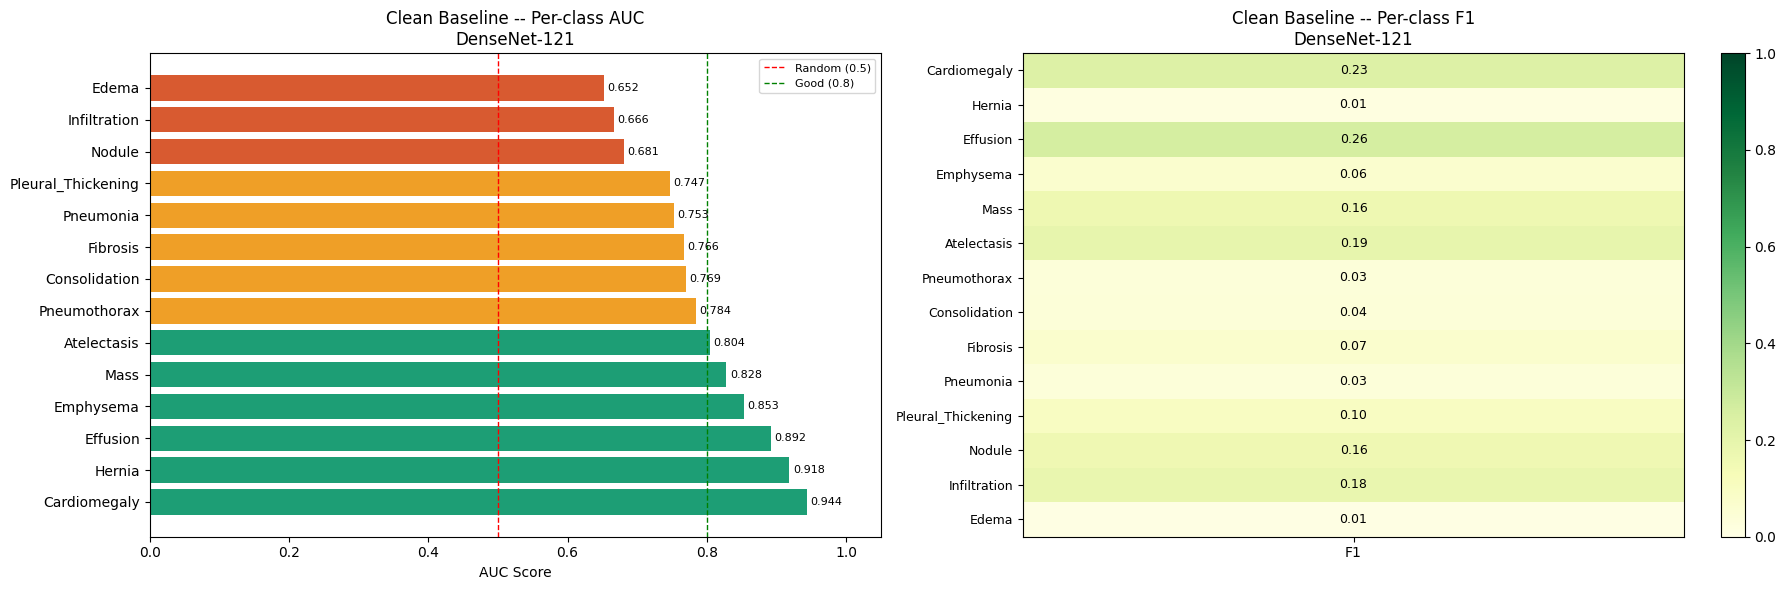

In [12]:
# Cell 8: Plot 1 -- AUC bar chart  |  Plot 2 -- Per-class F1 heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

names_sorted  = sorted(clean_per_class, key=lambda x: -clean_per_class[x]["AUC"])
auc_vals      = [clean_per_class[n]["AUC"] for n in names_sorted]
colours       = ["#1D9E75" if v >= 0.80 else "#EF9F27" if v >= 0.70 else "#D85A30" for v in auc_vals]

bars = axes[0].barh(names_sorted, auc_vals, color=colours, edgecolor="none")
axes[0].axvline(0.5, color="red", linestyle="--", linewidth=1, label="Random (0.5)")
axes[0].axvline(0.8, color="green", linestyle="--", linewidth=1, label="Good (0.8)")
for bar, val in zip(bars, auc_vals):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=8)
axes[0].set_xlabel("AUC Score")
axes[0].set_title("Clean Baseline -- Per-class AUC\nDenseNet-121")
axes[0].set_xlim(0, 1.05)
axes[0].legend(fontsize=8)

f1_vals = np.array([[clean_per_class[n]["F1"]] for n in names_sorted])
im = axes[1].imshow(f1_vals, cmap="YlGn", aspect="auto", vmin=0, vmax=1)
axes[1].set_xticks([0]); axes[1].set_xticklabels(["F1"])
axes[1].set_yticks(range(len(names_sorted))); axes[1].set_yticklabels(names_sorted, fontsize=9)
for i, val in enumerate(f1_vals):
    axes[1].text(0, i, f"{val[0]:.2f}", ha="center", va="center", fontsize=9, color="black")
plt.colorbar(im, ax=axes[1], fraction=0.046)
axes[1].set_title("Clean Baseline -- Per-class F1\nDenseNet-121")

plt.tight_layout()
plt.savefig("baseline_full.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Cell 9: Save to CSV
import csv

with open("baseline_results.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Disease", "Precision", "Recall", "F1", "AUC"])
    for name, m in clean_per_class.items():
        writer.writerow([name, round(m["Precision"], 4), round(m["Recall"], 4),
                         round(m["F1"], 4), round(m["AUC"], 4)])
    writer.writerow([])
    writer.writerow(["Micro F1", "", "", round(clean_agg["micro_f1"], 4), ""])
    writer.writerow(["Macro F1", "", "", round(clean_agg["macro_f1"], 4), ""])
    writer.writerow(["Mean AUC", "", "", "", round(clean_agg["mean_auc"], 4)])
    writer.writerow(["Hamming Loss", "", "", round(clean_agg["hamming_loss"], 4), ""])

print("Saved to baseline_results.csv")

Saved to baseline_results.csv


## Fine-tuning — FIXED

**What was broken:** the original loop rebuilt the 18→14 class alignment every
batch by writing into a fresh `torch.zeros(...)` tensor column-by-column inside
a Python loop, used no class weighting on a heavily imbalanced 14-disease
label set, and never printed a gradient-health signal — so the model trained
for 10 full epochs at `loss ≈ ln(2) = 0.693` (the loss you get when every
predicted probability is stuck at 0.5) without anyone being able to tell until
the run was already over.

**What's fixed below:**
1. A single precomputed index tensor + `index_select` for the class alignment — unambiguously gradient-safe, and computed once instead of every batch.
2. `pos_weight` in `BCEWithLogitsLoss`, computed from the real train-split class balance, so the model isn't just rewarded for predicting "no disease" everywhere.
3. Gradient-norm printed every epoch — if it's near zero, gradients aren't reaching the weights and you'll know on epoch 1, not epoch 10.
4. `AdamW` at a slightly lower LR (`5e-5` vs `1e-4`) with `ReduceLROnPlateau`, and gradient clipping for stability.
5. An explicit early warning if `train_loss` is still at the `ln(2)` collapse point after epoch 1.


In [14]:
# Cell 10 (FIXED): Fine-tuning setup
from sklearn.metrics import f1_score as sk_f1

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,
                          num_workers=2, pin_memory=(device.type == "cuda"))
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False,
                        num_workers=2, pin_memory=(device.type == "cuda"))

# ---- FIX: precompute a fixed dataset-order -> model-order index map once ----
# The old code rebuilt this mapping with slice-assignment into a fresh
# torch.zeros(...) tensor inside the innermost loop, every batch, every epoch.
# We replace it with a single precomputed index tensor + index_select --
# unambiguously differentiable, and computed once instead of ~14 times per batch.
matched_model_idx = []
for pname in dataset.pathologies:
    if pname in model.pathologies:
        matched_model_idx.append(list(model.pathologies).index(pname))
    else:
        matched_model_idx.append(None)

assert all(idx is not None for idx in matched_model_idx), \
    f"Unmapped pathologies: {[p for p, i in zip(dataset.pathologies, matched_model_idx) if i is None]}"

model_idx_tensor = torch.tensor(matched_model_idx, dtype=torch.long, device=device)

def align_logits(logits):
    """Gather the matching model output columns in dataset-pathology order."""
    return logits.index_select(1, model_idx_tensor)

# ---- FIX: positive-class weights to counter label imbalance ----
# NIH ChestX-ray14 is heavily imbalanced (most diseases are well under 10%
# positive). Without pos_weight, BCE's easiest low-loss path is often to push
# every logit toward "no disease" -- worth countering explicitly.
pos_counts, total_counts = torch.zeros(len(dataset.pathologies)), torch.zeros(len(dataset.pathologies))
for batch in train_loader:
    labels = batch["lab"]
    valid = ~torch.isnan(labels)
    pos_counts   += torch.nan_to_num(labels, nan=0.0).clamp(min=0).sum(dim=0)
    total_counts += valid.sum(dim=0).float()
pos_weight = ((total_counts - pos_counts) / pos_counts.clamp(min=1)).clamp(max=20.0).to(device)

print("Per-class pos_weight (capped at 20):")
for name, w in zip(dataset.pathologies, pos_weight.cpu().numpy()):
    print(f"  {name:<22} {w:.2f}")

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ---- FIX: confirm nothing is frozen, use a slightly lower LR ----
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_trainable:,} / {sum(p.numel() for p in model.parameters()):,}")
assert n_trainable > 0, "Model has no trainable parameters -- check requires_grad."

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Optimizer     : AdamW  lr=5e-5")
print(f"Loss          : BCEWithLogitsLoss (with pos_weight)")
print(f"Scheduler     : ReduceLROnPlateau patience=2")

Per-class pos_weight (capped at 20):
  Atelectasis            15.68
  Cardiomegaly           20.00
  Consolidation          20.00
  Edema                  20.00
  Effusion               20.00
  Emphysema              20.00
  Fibrosis               20.00
  Hernia                 20.00
  Infiltration           11.29
  Mass                   20.00
  Nodule                 16.63
  Pleural_Thickening     20.00
  Pneumonia              20.00
  Pneumothorax           20.00

Trainable parameters: 6,966,034 / 6,966,034

Train batches : 751
Val batches   : 81
Optimizer     : AdamW  lr=5e-5
Loss          : BCEWithLogitsLoss (with pos_weight)
Scheduler     : ReduceLROnPlateau patience=2


In [15]:
# Cell 11 (FIXED): Fine-tuning loop -- 10 epochs
EPOCHS = 10
GRAD_CLIP = 5.0
best_model_path = "/home/working/densenet121_finetuned.pth"

# ---- CHECKPOINT: skip training entirely if weights already exist ----
# Set FORCE_RETRAIN_FINETUNE = True to ignore any saved checkpoint and retrain
# from scratch (e.g. after changing the training code or dataset).
FORCE_RETRAIN_FINETUNE = False

train_losses, val_losses = [], []
train_f1s, val_f1s = [], []
best_val_loss = float("inf")

# BUGFIX: this loop used to read the global `threshold`, which was computed back
# in the clean-eval cell from the PRETRAINED model's probabilities -- i.e. a
# threshold that has nothing to do with the model actually being trained here.
# It never touched the loss/gradients (cosmetic only), but it made the live
# train_f1/val_f1 printed each epoch misleading. Decoupled from that stale
# value with a fixed 0.5 for training-time monitoring; the real, properly
# calibrated per-class thresholds are computed later for actual evaluation.
monitor_threshold = 0.5

if os.path.exists(best_model_path) and not FORCE_RETRAIN_FINETUNE:
    print(f"Found existing checkpoint: {best_model_path} -- loading it and skipping training.")
    print("(set FORCE_RETRAIN_FINETUNE = True above to force a fresh training run)")
    model.load_state_dict(torch.load(best_model_path))
    model.eval()
else:
    print("No checkpoint found (or FORCE_RETRAIN_FINETUNE=True) -- starting fine-tuning...")
    print("="*70)

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        grad_norms = []
        train_preds_all, train_labels_all = [], []

        for batch in train_loader:
            images = batch["img"].to(device)
            labels = batch["lab"].to(device)

            labels_clean = labels.clone().float()
            labels_clean[torch.isnan(labels_clean)] = 0.0
            labels_clean[labels_clean == -1] = 0.0

            optimizer.zero_grad()
            logits = model(images)
            logits_aligned = align_logits(logits)          # FIX: gather-based, gradient-safe

            loss = criterion(logits_aligned, labels_clean)
            loss.backward()

            # FIX: clip + record gradient norm as a per-epoch health check
            total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            grad_norms.append(total_norm.item())

            optimizer.step()
            running_loss += loss.item()

            preds = (torch.sigmoid(logits_aligned) > monitor_threshold).int().cpu().numpy()
            train_preds_all.append(preds)
            train_labels_all.append(labels_clean.int().cpu().numpy())

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)
        avg_grad_norm = float(np.mean(grad_norms))

        tp = np.concatenate(train_preds_all, axis=0)
        tl = np.concatenate(train_labels_all, axis=0)
        train_f1 = sk_f1(tl.flatten(), tp.flatten(), zero_division=0, average="macro")
        train_f1s.append(train_f1)

        # Validation
        model.eval()
        val_loss_total = 0.0
        val_preds_all, val_labels_all = [], []

        with torch.no_grad():
            for batch in val_loader:
                images = batch["img"].to(device)
                labels = batch["lab"].to(device)
                labels_clean = labels.clone().float()
                labels_clean[torch.isnan(labels_clean)] = 0.0
                labels_clean[labels_clean == -1] = 0.0

                logits = model(images)
                logits_aligned = align_logits(logits)
                loss = criterion(logits_aligned, labels_clean)
                val_loss_total += loss.item()

                preds = (torch.sigmoid(logits_aligned) > monitor_threshold).int().cpu().numpy()
                val_preds_all.append(preds)
                val_labels_all.append(labels_clean.int().cpu().numpy())

        val_loss = val_loss_total / len(val_loader)
        val_losses.append(val_loss)

        vp = np.concatenate(val_preds_all, axis=0)
        vl = np.concatenate(val_labels_all, axis=0)
        val_f1 = sk_f1(vl.flatten(), vp.flatten(), zero_division=0, average="macro")
        val_f1s.append(val_f1)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            saved_marker = " <- saved best"
        else:
            saved_marker = ""

        print(f"Epoch {epoch+1:02d}/{EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
              f"train_f1={train_f1:.4f}  val_f1={val_f1:.4f}  grad_norm={avg_grad_norm:.3f}{saved_marker}")

        if epoch == 0 and abs(train_loss - 0.693) < 0.01:
            print("  WARNING: train_loss ~ ln(2) after epoch 1 -- output stuck near p=0.5.")
            print("  If this persists next epoch, check grad_norm above: near-zero means")
            print("  gradients aren't reaching the weights (re-check requires_grad / graph).")

    print("="*70)
    print(f"Fine-tuning done. Best val loss : {best_val_loss:.4f}")
    print(f"Best model saved to             : {best_model_path}")

    # reload the BEST checkpoint (not necessarily the last epoch) before moving on
    model.load_state_dict(torch.load(best_model_path))
    model.eval()

Found existing checkpoint: /home/working/densenet121_finetuned.pth -- loading it and skipping training.
(set FORCE_RETRAIN_FINETUNE = True above to force a fresh training run)


In [16]:
# Cell 12: Fine-tuning training curves
if len(train_losses) == 0:
    print("Training was skipped (loaded from checkpoint) -- no curves to plot for this run.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs_x = range(1, len(train_losses) + 1)

    axes[0].plot(epochs_x, train_losses, "b-o", label="Train Loss")
    axes[0].plot(epochs_x, val_losses,   "r-o", label="Val Loss")
    axes[0].axhline(0.693, color="gray", linestyle=":", label="ln(2) collapse point")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Fine-tuning -- Loss Curves\nDenseNet-121")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_x, train_f1s, "b-o", label="Train Macro-F1")
    axes[1].plot(epochs_x, val_f1s,   "r-o", label="Val Macro-F1")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro F1")
    axes[1].set_title("Fine-tuning -- Macro F1 Curves\nDenseNet-121")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("finetuning_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved finetuning_curves.png")

Training was skipped (loaded from checkpoint) -- no curves to plot for this run.


In [17]:
# Cell 13: Evaluate fine-tuned model on clean test set
model.load_state_dict(torch.load(best_model_path))
model.eval()

ft_probs, ft_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        images = batch["img"].to(device)
        labels = batch["lab"]
        logits = model(images)
        probs_aligned = torch.sigmoid(align_logits(logits)).cpu().numpy()
        ft_probs.append(probs_aligned)
        ft_labels.append(labels.numpy())

ft_probs  = np.concatenate(ft_probs, axis=0)
ft_labels = np.concatenate(ft_labels, axis=0).astype(float)
ft_labels[ft_labels == -1] = np.nan

ft_threshold = float(ft_probs.mean())
ft_per_class, ft_agg = compute_full_metrics(ft_probs, ft_labels, dataset.pathologies, threshold=ft_threshold)

print("="*72)
print(f"{'Metric':<20} {'Pretrained':>15} {'Fine-tuned':>15}")
print("-"*72)
print(f"{'Mean AUC':<20} {clean_agg['mean_auc']:>15.4f} {ft_agg['mean_auc']:>15.4f}")
print(f"{'Macro F1':<20} {clean_agg['macro_f1']:>15.4f} {ft_agg['macro_f1']:>15.4f}")
print(f"{'Micro F1':<20} {clean_agg['micro_f1']:>15.4f} {ft_agg['micro_f1']:>15.4f}")
print(f"{'Hamming Loss':<20} {clean_agg['hamming_loss']:>15.4f} {ft_agg['hamming_loss']:>15.4f}")
print("="*72)

Metric                    Pretrained      Fine-tuned
------------------------------------------------------------------------
Mean AUC                      0.7899          0.7842
Macro F1                      0.1099          0.1564
Micro F1                      0.1112          0.2056
Hamming Loss                  0.4251          0.1604


In [18]:
# Cell 13b: Per-class threshold calibration on validation set
from sklearn.metrics import precision_recall_curve

def compute_per_class_thresholds(probs, labels, pathology_names, fallback=0.5):
    thresholds = {}
    for i, name in enumerate(pathology_names):
        l = labels[:, i]
        valid = ~np.isnan(l)
        l_valid = l[valid].astype(int)
        p_valid = probs[:, i][valid]
        if len(np.unique(l_valid)) < 2:
            thresholds[name] = fallback
            continue
        prec, rec, thresh = precision_recall_curve(l_valid, p_valid)
        f1s = 2 * prec * rec / (prec + rec + 1e-8)
        thresholds[name] = float(thresh[np.argmax(f1s[:-1])]) if len(thresh) else fallback
    return thresholds

# Evaluate fine-tuned model on the VAL set (not test) to pick thresholds --
# picking thresholds on test data would leak test info into your metrics.
model.eval()
val_probs_ft, val_labels_ft = [], []
with torch.no_grad():
    for batch in val_loader:
        images = batch["img"].to(device)
        logits = model(images)
        val_probs_ft.append(torch.sigmoid(align_logits(logits)).cpu().numpy())
        val_labels_ft.append(batch["lab"].numpy())
val_probs_ft  = np.concatenate(val_probs_ft, axis=0)
val_labels_ft = np.concatenate(val_labels_ft, axis=0).astype(float)
val_labels_ft[val_labels_ft == -1] = np.nan

per_class_thresh = compute_per_class_thresholds(val_probs_ft, val_labels_ft, dataset.pathologies, fallback=ft_threshold)

print("Per-class thresholds (F1-optimal on val set):")
for name, t in per_class_thresh.items():
    print(f"  {name:<22} {t:.4f}")

# Sanity check: re-run clean test eval with per-class thresholds vs the old global one
ft_per_class_v2, ft_agg_v2 = compute_full_metrics(ft_probs, ft_labels, dataset.pathologies, threshold=per_class_thresh)
print("\nGlobal scalar threshold  -- Micro F1:", round(ft_agg["micro_f1"], 4), " Macro F1:", round(ft_agg["macro_f1"], 4))
print("Per-class thresholds     -- Micro F1:", round(ft_agg_v2["micro_f1"], 4), " Macro F1:", round(ft_agg_v2["macro_f1"], 4))

# Check Hernia specifically -- this is the class that was broken (recall=1.0, precision~0)
if "Hernia" in ft_per_class_v2:
    print("\nHernia with per-class threshold:", ft_per_class_v2["Hernia"])

Per-class thresholds (F1-optimal on val set):
  Atelectasis            0.6576
  Cardiomegaly           0.6664
  Consolidation          0.5772
  Edema                  0.5032
  Effusion               0.7165
  Emphysema              0.6225
  Fibrosis               0.5367
  Hernia                 0.6225
  Infiltration           0.5808
  Mass                   0.6567
  Nodule                 0.6261
  Pleural_Thickening     0.5716
  Pneumonia              0.5043
  Pneumothorax           0.5054

Global scalar threshold  -- Micro F1: 0.2056  Macro F1: 0.1564
Per-class thresholds     -- Micro F1: 0.2592  Macro F1: 0.2004

Hernia with per-class threshold: {'AUC': 0.8081654754169374, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}


In [43]:
import csv

with open("finetuned_results.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Disease", "Precision", "Recall", "F1", "AUC", "Threshold"])
    for name, m in ft_per_class_v2.items():
        writer.writerow([name, round(m["Precision"], 4), round(m["Recall"], 4),
                         round(m["F1"], 4), round(m["AUC"], 4), round(per_class_thresh[name], 4)])
    writer.writerow([])
    writer.writerow(["Micro F1", "", "", round(ft_agg_v2["micro_f1"], 4), "", ""])
    writer.writerow(["Macro F1", "", "", round(ft_agg_v2["macro_f1"], 4), "", ""])
    writer.writerow(["Mean AUC", "", "", "", round(ft_agg_v2["mean_auc"], 4), ""])
    writer.writerow(["Hamming Loss", "", "", round(ft_agg_v2["hamming_loss"], 4), "", ""])

print("Saved to finetuned_results.csv")

Saved to finetuned_results.csv


In [19]:
# Save sample images for Person B's interface later
sample_images, sample_labels = [], []
for i in range(20):
    sample = test_ds[i]
    sample_images.append(np.array(sample["img"]))
    sample_labels.append(np.array(sample["lab"]))

np.save("sample_images.npy", np.array(sample_images))
np.save("sample_labels.npy", np.array(sample_labels))
print("Saved 20 sample images for interface use.")

Saved 20 sample images for interface use.


## Attacks — FGSM, PGD, DeepFool (fast, full test set) + real C&W and Square Attack (slow, subset)

> **Note on FGSM/PGD and multi-label targets:** foolbox's built-in `FGSM`/`LinfPGD` are single-label attacks, so each image is reduced to one "true class" via `labels.argmax(dim=1)` below. For a fully healthy image (all-zero label vector) or a multi-disease image, that collapses to an arbitrary single index, which muddies what "attack success" means for FGSM/PGD specifically. This is a known limitation of using foolbox's stock attacks on a multi-label task -- it's why DeepFool, C&W, and Square Attack further down are custom multi-label reimplementations instead. Left as-is here since a full multi-label FGSM/PGD would be a bigger redesign; treat the FGSM/PGD numbers as a rough/approximate signal rather than an exact multi-label attack.

In [20]:
# OPT: apply_clahe_batch is defined here (moved up from the CLAHE section
# further down) so the FGSM/PGD/DeepFool attack loops in this section can
# evaluate each freshly crafted adversarial batch BOTH with and without CLAHE
# in a single pass. Previously, FGSM/PGD/DeepFool were each crafted against
# this exact fine-tuned model twice: once here for the baseline "no defense"
# numbers, and again from scratch in the CLAHE section just to add CLAHE on
# top -- same weights, same attack, only the post-processing differed. Fusing
# the two into one pass avoids paying for the expensive gradient-based
# crafting step twice.
import cv2

_clahe_obj_cache = {}
def _get_clahe(clip_limit, tile_grid_size):
    key = (clip_limit, tile_grid_size)
    if key not in _clahe_obj_cache:
        _clahe_obj_cache[key] = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return _clahe_obj_cache[key]

def apply_clahe_batch(images_tensor, clip_limit=2.0, tile_grid_size=(8, 8)):
    imgs = images_tensor.detach().cpu().numpy()
    clahe = _get_clahe(clip_limit, tile_grid_size)

    img_min = imgs.min(axis=(2, 3), keepdims=True)
    img_max = imgs.max(axis=(2, 3), keepdims=True)
    span = np.where((img_max - img_min) > 1e-8, img_max - img_min, 1e-8)
    imgs_u8 = ((imgs - img_min) / span * 255).astype(np.uint8)

    out = np.zeros_like(imgs)
    for i in range(imgs.shape[0]):
        img_clahe_u8 = clahe.apply(imgs_u8[i, 0])
        out[i, 0] = img_clahe_u8.astype(np.float32) / 255.0 * span[i, 0, 0, 0] + img_min[i, 0, 0, 0]
    return torch.from_numpy(out).to(images_tensor.device).float()


In [21]:
# Cell A: FGSM Attack
import foolbox as fb

model.eval()
fmodel = fb.PyTorchModel(model, bounds=(-1024, 1024))
epsilons = [8.0, 16.0, 32.0]

fgsm_attack     = fb.attacks.FGSM()
fgsm_all_probs  = {eps: [] for eps in epsilons}
fgsm_all_labels = []

# OPT: also evaluate the CLAHE-defended version of each freshly crafted batch
# here, instead of re-running FGSM against this exact fine-tuned model a
# second time in the CLAHE section further down. Same attack, same weights --
# only the post-processing differs.
clahe_fgsm_probs = {eps: [] for eps in epsilons}

print("Running FGSM attack...")
for i, batch in enumerate(test_loader):
    images       = batch["img"].to(device)
    labels       = batch["lab"]
    class_labels = labels.argmax(dim=1).to(device)

    _, clipped, _ = fgsm_attack(fmodel, images, class_labels, epsilons=epsilons)
    fgsm_all_labels.append(labels.numpy())

    for j, eps in enumerate(epsilons):
        with torch.no_grad():
            raw_probs = torch.sigmoid(align_logits(model(clipped[j]))).cpu().numpy()
        fgsm_all_probs[eps].append(raw_probs)

        defended = apply_clahe_batch(clipped[j])
        with torch.no_grad():
            clahe_probs = torch.sigmoid(align_logits(model(defended))).cpu().numpy()
        clahe_fgsm_probs[eps].append(clahe_probs)

    if i % 10 == 0:
        print(f"  Batch {i}/{len(test_loader)}")

fgsm_all_labels = np.concatenate(fgsm_all_labels, axis=0).astype(float)
fgsm_all_labels[fgsm_all_labels == -1] = np.nan
for eps in epsilons:
    fgsm_all_probs[eps]   = np.concatenate(fgsm_all_probs[eps], axis=0)
    clahe_fgsm_probs[eps] = np.concatenate(clahe_fgsm_probs[eps], axis=0)
clahe_fgsm_labels = fgsm_all_labels  # same images, same order -- labels are identical

print("FGSM done (clean + CLAHE variants computed together).")

Running FGSM attack...
  Batch 0/81
  Batch 10/81
  Batch 20/81
  Batch 30/81
  Batch 40/81
  Batch 50/81
  Batch 60/81
  Batch 70/81
  Batch 80/81
FGSM done (clean + CLAHE variants computed together).


In [22]:
# Cell B: PGD Attack
pgd_attack     = fb.attacks.LinfPGD(steps=20, abs_stepsize=2.0)
pgd_all_probs  = {eps: [] for eps in epsilons}
pgd_all_labels = []

# OPT: same reasoning as the FGSM cell above -- evaluate the CLAHE-defended
# version of each freshly crafted batch here too, instead of re-running PGD
# against this exact fine-tuned model a second time later.
clahe_pgd_probs = {eps: [] for eps in epsilons}

print("Running PGD attack (slower)...")
for i, batch in enumerate(test_loader):
    images       = batch["img"].to(device)
    labels       = batch["lab"]
    class_labels = labels.argmax(dim=1).to(device)

    _, clipped, _ = pgd_attack(fmodel, images, class_labels, epsilons=epsilons)
    pgd_all_labels.append(labels.numpy())

    for j, eps in enumerate(epsilons):
        with torch.no_grad():
            raw_probs = torch.sigmoid(align_logits(model(clipped[j]))).cpu().numpy()
        pgd_all_probs[eps].append(raw_probs)

        defended = apply_clahe_batch(clipped[j])
        with torch.no_grad():
            clahe_probs = torch.sigmoid(align_logits(model(defended))).cpu().numpy()
        clahe_pgd_probs[eps].append(clahe_probs)

    if i % 10 == 0:
        print(f"  Batch {i}/{len(test_loader)}")

pgd_all_labels = np.concatenate(pgd_all_labels, axis=0).astype(float)
pgd_all_labels[pgd_all_labels == -1] = np.nan
for eps in epsilons:
    pgd_all_probs[eps]   = np.concatenate(pgd_all_probs[eps], axis=0)
    clahe_pgd_probs[eps] = np.concatenate(clahe_pgd_probs[eps], axis=0)
clahe_pgd_labels = pgd_all_labels

print("PGD done (clean + CLAHE variants computed together).")

Running PGD attack (slower)...
  Batch 0/81
  Batch 10/81
  Batch 20/81
  Batch 30/81
  Batch 40/81
  Batch 50/81
  Batch 60/81
  Batch 70/81
  Batch 80/81
PGD done (clean + CLAHE variants computed together).


### DeepFool Attack

DeepFool finds the smallest perturbation that pushes an image across the
model's decision boundary, by iteratively linearizing the model locally and
stepping toward the nearest boundary. It's white-box (uses gradients),
faster than C&W since it doesn't run a full optimization loop, and produces
smaller, more surgical perturbations than FGSM/PGD. Runs on the full test
set, same as FGSM and PGD.

In [23]:
# Cell B2 (FIXED): Multi-label DeepFool -- custom, minimal-perturbation attack
# NOTE: foolbox's LinfDeepFoolAttack only understands single-label argmax
# classification -- it stops as soon as it flips ONE class, ignoring the
# other 13. This version keeps DeepFool's core idea (minimal perturbation,
# stop once the objective is satisfied) but defines "satisfied" as: every
# true label has flipped across its threshold, using multi-label BCE gradients.

class MultiLabelDeepFool:
    def __init__(self, max_steps=50, step_frac=0.1, thresholds=None, pathology_names=None):
        self.max_steps = max_steps
        self.step_frac = step_frac
        self.thresholds = thresholds
        self.pathology_names = pathology_names

    def _thresh_vec(self, n_classes, device):
        if self.thresholds is None:
            return torch.full((n_classes,), 0.5, device=device)
        return torch.tensor([self.thresholds.get(n, 0.5) for n in self.pathology_names], device=device)

    def __call__(self, fmodel, images, labels_multihot, epsilons):
        single = not isinstance(epsilons, (list, tuple))
        eps_list = [epsilons] if single else epsilons
        clipped = [self._attack_one_eps(fmodel, images, labels_multihot, eps) for eps in eps_list]
        with torch.no_grad():
            success = torch.stack([self._flip_count(fmodel, adv, labels_multihot) >
                                    self._flip_count(fmodel, images, labels_multihot) for adv in clipped])
        if single:
            return clipped[0], clipped[0], success[0]
        return clipped, clipped, success

    def _flip_count(self, fmodel, x, labels_multihot):
        with torch.no_grad():
            probs = torch.sigmoid(align_logits(fmodel(x)))
            labels_clean = labels_multihot.clone().float()
            labels_clean[torch.isnan(labels_clean)] = 0.0
            labels_clean[labels_clean == -1] = 0.0
            thresh_vec = self._thresh_vec(probs.shape[1], x.device)
            pos_flipped = ((labels_clean == 1) & (probs <= thresh_vec)).sum(dim=1)
            neg_flipped = ((labels_clean == 0) & (probs > thresh_vec)).sum(dim=1)
            return pos_flipped + neg_flipped

    def _attack_one_eps(self, fmodel, images, labels_multihot, epsilon):
        labels_clean = labels_multihot.clone().float()
        labels_clean[torch.isnan(labels_clean)] = 0.0
        labels_clean[labels_clean == -1] = 0.0
        thresh_vec = self._thresh_vec(labels_clean.shape[1], images.device)
        step_size = self.step_frac * epsilon

        x_adv = images.clone().detach()
        for it in range(self.max_steps):
            x_adv.requires_grad_(True)
            probs = torch.sigmoid(align_logits(fmodel(x_adv)))
            pos_mask = (labels_clean == 1) & (probs > thresh_vec)
            neg_mask = (labels_clean == 0) & (probs <= thresh_vec)
            active = pos_mask | neg_mask
            if active.sum() == 0:
                break

            loss = (probs * pos_mask.float() - probs * neg_mask.float()).sum()
            grad = torch.autograd.grad(loss, x_adv)[0]

            x_adv = x_adv.detach() - step_size * grad.sign()
            delta = torch.clamp(x_adv - images, -epsilon, epsilon)
            x_adv = torch.clamp(images + delta, images.min(), images.max()).detach()

        return x_adv


deepfool_attack     = MultiLabelDeepFool(max_steps=50, step_frac=0.1,
                                          thresholds=per_class_thresh, pathology_names=dataset.pathologies)
deepfool_all_probs  = {eps: [] for eps in epsilons}
deepfool_all_labels = []

# OPT: same reasoning as FGSM/PGD above -- also evaluate the CLAHE-defended
# version of each freshly crafted batch here, instead of re-running DeepFool
# (the most expensive of the three, up to 50 steps/image) against this exact
# fine-tuned model a second time later.
clahe_df_probs = {eps: [] for eps in epsilons}

print("Running multi-label DeepFool attack...")
for i, batch in enumerate(test_loader):
    images          = batch["img"].to(device)
    labels          = batch["lab"]
    labels_multihot = labels.to(device)
    _, clipped, _ = deepfool_attack(fmodel, images, labels_multihot, epsilons=epsilons)
    deepfool_all_labels.append(labels.numpy())
    for j, eps in enumerate(epsilons):
        with torch.no_grad():
            raw_probs = torch.sigmoid(align_logits(model(clipped[j]))).cpu().numpy()
        deepfool_all_probs[eps].append(raw_probs)

        defended = apply_clahe_batch(clipped[j])
        with torch.no_grad():
            clahe_probs = torch.sigmoid(align_logits(model(defended))).cpu().numpy()
        clahe_df_probs[eps].append(clahe_probs)
    if i % 10 == 0:
        print(f"  Batch {i}/{len(test_loader)}")
deepfool_all_labels = np.concatenate(deepfool_all_labels, axis=0).astype(float)
deepfool_all_labels[deepfool_all_labels == -1] = np.nan
for eps in epsilons:
    deepfool_all_probs[eps] = np.concatenate(deepfool_all_probs[eps], axis=0)
    clahe_df_probs[eps]     = np.concatenate(clahe_df_probs[eps], axis=0)
clahe_df_labels = deepfool_all_labels

print("Multi-label DeepFool done (clean + CLAHE variants computed together).")

Running multi-label DeepFool attack...
  Batch 0/81
  Batch 10/81
  Batch 20/81
  Batch 30/81
  Batch 40/81
  Batch 50/81
  Batch 60/81
  Batch 70/81
  Batch 80/81
Multi-label DeepFool done (clean + CLAHE variants computed together).


In [24]:
import gc, torch
torch.cuda.empty_cache()
gc.collect()
print(f"{torch.cuda.memory_allocated()/1e9:.2f} GB allocated / {torch.cuda.memory_reserved()/1e9:.2f} GB reserved")

0.09 GB allocated / 0.13 GB reserved


### Attack evaluation subset for C&W and Square Attack

C&W (500 optimization steps per image) and Square Attack (hundreds of
black-box queries per image) are far more expensive per image than
FGSM/PGD/DeepFool. Running them on the full test set on a single Kaggle GPU
can take hours. We evaluate them on a fixed random subset instead — standard
practice in adversarial-robustness papers when compute is limited. Increase
`ATTACK_SUBSET_SIZE` if you have the GPU budget.

In [25]:
ATTACK_SUBSET_SIZE = 300
rng = random.Random(42)
subset_indices = rng.sample(range(len(test_ds)), min(ATTACK_SUBSET_SIZE, len(test_ds)))
attack_eval_ds = Subset(test_ds, subset_indices)
attack_eval_loader = DataLoader(attack_eval_ds, batch_size=16, shuffle=False,
                                num_workers=2, pin_memory=(device.type == "cuda"))
print(f"C&W / Square will be evaluated on {len(attack_eval_ds)} images "
      f"(out of {len(test_ds)} in the full test set).")

subset_clean_probs, subset_clean_labels = [], []
with torch.no_grad():
    for batch in attack_eval_loader:
        images = batch["img"].to(device)
        labels = batch["lab"]
        probs_aligned = torch.sigmoid(align_logits(model(images))).cpu().numpy()
        subset_clean_probs.append(probs_aligned)
        subset_clean_labels.append(labels.numpy())
subset_clean_probs  = np.concatenate(subset_clean_probs, axis=0)
subset_clean_labels = np.concatenate(subset_clean_labels, axis=0).astype(float)
subset_clean_labels[subset_clean_labels == -1] = np.nan

_, subset_clean_agg = compute_full_metrics(subset_clean_probs, subset_clean_labels,
                                           dataset.pathologies, threshold=ft_threshold)
print(f"Clean mean AUC on this subset: {subset_clean_agg['mean_auc']:.4f} "
      f"(full test set: {ft_agg['mean_auc']:.4f})")

C&W / Square will be evaluated on 300 images (out of 2574 in the full test set).
Clean mean AUC on this subset: 0.7793 (full test set: 0.7842)


In [26]:
# Cell C (FIXED): Multi-label C&W -- Adam-optimized margin loss over all true labels
class MultiLabelCW:
    def __init__(self, steps=100, lr=0.05, thresholds=None, pathology_names=None):
        self.steps = steps
        self.lr = lr
        self.thresholds = thresholds
        self.pathology_names = pathology_names

    def _thresh_vec(self, n_classes, device):
        if self.thresholds is None:
            return torch.full((n_classes,), 0.5, device=device)
        return torch.tensor([self.thresholds.get(n, 0.5) for n in self.pathology_names], device=device)

    def __call__(self, fmodel, images, labels_multihot, epsilons):
        single = not isinstance(epsilons, (list, tuple))
        eps_list = [epsilons] if single else epsilons
        clipped = [self._attack_one_eps(fmodel, images, labels_multihot, eps) for eps in eps_list]
        with torch.no_grad():
            success = torch.stack([torch.ones(images.shape[0], dtype=torch.bool, device=images.device) for _ in clipped])
        if single:
            return clipped[0], clipped[0], success[0]
        return clipped, clipped, success

    def _attack_one_eps(self, fmodel, images, labels_multihot, epsilon):
        labels_clean = labels_multihot.clone().float()
        labels_clean[torch.isnan(labels_clean)] = 0.0
        labels_clean[labels_clean == -1] = 0.0
        thresh_vec = self._thresh_vec(labels_clean.shape[1], images.device)

        # BUGFIX 1: random init within the epsilon ball, instead of starting from
        # delta = 0. Starting at the clean image means the model is often already
        # confidently/correctly predicting there, which puts the margin loss in a
        # flat, low-gradient region (probs saturated near 0 or 1) -- a slow place
        # to start a gradient-based search from. A random start is standard
        # practice for PGD-style attacks for exactly this reason.
        delta = ((torch.rand_like(images) * 2 - 1) * epsilon).clone().detach().requires_grad_(True)

        # BUGFIX 2: lr scaled to epsilon. The old fixed lr=0.05 is sized for a
        # roughly [0,1] or [-1,1] pixel space; these images are raw intensities
        # (~+/-1024), and epsilon itself ranges 8-32. Adam's per-step movement is
        # roughly O(lr), so at lr=0.05 over 100 steps the perturbation could only
        # ever reach a cumulative magnitude of ~5 -- never even reaching the
        # epsilon=8 boundary, let alone 16 or 32. Scaling lr with epsilon lets the
        # optimizer actually use the full perturbation budget it's allowed.
        lr = max(self.lr, epsilon / 15.0)
        optimizer = torch.optim.Adam([delta], lr=lr)

        for it in range(self.steps):
            x_adv = torch.clamp(images + torch.clamp(delta, -epsilon, epsilon), images.min(), images.max())
            probs = torch.sigmoid(align_logits(fmodel(x_adv)))

            pos_margin = torch.relu(probs - thresh_vec) * (labels_clean == 1).float()
            neg_margin = torch.relu(thresh_vec - probs) * (labels_clean == 0).float()

            # BUGFIX 3: the L2 regularizer was `0.01 * delta.pow(2).sum()` over a
            # [B,1,224,224] tensor of raw-intensity values -- at delta near the
            # epsilon boundary that term is on the order of 1e4-1e5 (e.g. ~5x10^5
            # for a 16-image batch at epsilon=8), versus a margin loss that can
            # never exceed 14 per image (14 pathologies, each term in [0,1]). The
            # regularizer was completely swamping the attack objective, so Adam
            # was mostly just minimizing ||delta|| back toward zero rather than
            # flipping predictions -- this alone likely explains most of the
            # "suboptimal" C&W results. Rewritten as a per-image mean of
            # (delta/epsilon)^2, which is O(1) regardless of image size or
            # epsilon, then summed over the batch to match how the margin loss is
            # accumulated. This keeps a mild preference for smaller perturbations
            # (a real C&W attack cares about imperceptibility) without letting it
            # dominate the actual attack objective -- and the epsilon-ball clamp
            # above already guarantees imperceptibility regardless.
            delta_norm_sq = (delta / epsilon).pow(2).mean(dim=(1, 2, 3))
            loss = (pos_margin + neg_margin).sum() + 0.1 * delta_norm_sq.sum()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # OPT: early-stop once every positive/negative margin in the batch is
            # already satisfied (all labels successfully flipped) -- mirrors the
            # early-exit already used in DeepFool below. Only kicks in after a
            # short warm-up so we don't bail before Adam has had a chance to move.
            if it >= 10 and float((pos_margin + neg_margin).max()) < 1e-4:
                break

        with torch.no_grad():
            x_adv = torch.clamp(images + torch.clamp(delta, -epsilon, epsilon), images.min(), images.max())
        return x_adv.detach()


cw_attack     = MultiLabelCW(steps=100, lr=0.05, thresholds=per_class_thresh, pathology_names=dataset.pathologies)
cw_all_probs  = {eps: [] for eps in epsilons}
cw_all_labels = []

# OPT: also cache the raw clipped adversarial images (crafted against the
# fine-tuned `model`) per epsilon. C&W is the most expensive attack in this
# notebook (100 Adam steps/image/eps), and the CLAHE-only defense section below
# evaluates this *same* fine-tuned model with the *same* attack -- just with an
# extra preprocessing step. Caching here lets that section skip re-running the
# whole attack from scratch. (The robust-model sections further down still have
# to recompute, since those attack a genuinely different set of weights.)
cw_adv_cache = {eps: [] for eps in epsilons}

print("Running multi-label C&W attack (100 Adam steps per epsilon -- slow, be patient)...")
for i, batch in enumerate(attack_eval_loader):
    images          = batch["img"].to(device)
    labels          = batch["lab"]
    labels_multihot = labels.to(device)
    _, clipped, _ = cw_attack(fmodel, images, labels_multihot, epsilons=epsilons)
    cw_all_labels.append(labels.numpy())
    for j, eps in enumerate(epsilons):
        with torch.no_grad():
            raw_probs = torch.sigmoid(align_logits(model(clipped[j]))).cpu().numpy()
        cw_all_probs[eps].append(raw_probs)
        cw_adv_cache[eps].append(clipped[j].detach().cpu())
    del clipped, images
    torch.cuda.empty_cache(); gc.collect()
    print(f"  Batch {i+1}/{len(attack_eval_loader)}")
cw_all_labels = np.concatenate(cw_all_labels, axis=0).astype(float)
cw_all_labels[cw_all_labels == -1] = np.nan
for eps in epsilons:
    cw_all_probs[eps] = np.concatenate(cw_all_probs[eps], axis=0)
cw_adv_images = {eps: torch.cat(cw_adv_cache[eps], dim=0) for eps in epsilons}
print("Multi-label C&W done.")

Running multi-label C&W attack (100 Adam steps per epsilon -- slow, be patient)...
  Batch 1/19
  Batch 2/19
  Batch 3/19
  Batch 4/19
  Batch 5/19
  Batch 6/19
  Batch 7/19
  Batch 8/19
  Batch 9/19
  Batch 10/19
  Batch 11/19
  Batch 12/19
  Batch 13/19
  Batch 14/19
  Batch 15/19
  Batch 16/19
  Batch 17/19
  Batch 18/19
  Batch 19/19
Multi-label C&W done.


In [27]:
# Cell D (FIXED): Custom Linf Square Attack -- black-box, multi-label objective
class LinfSquareAttack:
    def __init__(self, queries=300, p_init=0.05):
        self.queries = queries
        self.p_init = p_init

    def __call__(self, fmodel, images, labels_multihot, epsilons):
        single = not isinstance(epsilons, (list, tuple))
        eps_list = [epsilons] if single else epsilons
        clipped = [self._attack_one_eps(fmodel, images, labels_multihot, eps) for eps in eps_list]
        with torch.no_grad():
            success = torch.stack([
                self._score(fmodel, adv, labels_multihot) > self._score(fmodel, images, labels_multihot)
                for adv in clipped
            ])
        if single:
            return clipped[0], clipped[0], success[0]
        return clipped, clipped, success

    def _score(self, fmodel, x, labels_multihot):
        with torch.no_grad():
            logits = align_logits(fmodel(x))
            labels_clean = labels_multihot.clone().float()
            labels_clean[torch.isnan(labels_clean)] = 0.0
            labels_clean[labels_clean == -1] = 0.0
            probs = torch.sigmoid(logits)
            bce = -(labels_clean * torch.log(probs + 1e-8) +
                     (1 - labels_clean) * torch.log(1 - probs + 1e-8))
            return bce.sum(dim=1)

    def _attack_one_eps(self, fmodel, images, labels_multihot, epsilon):
        device = images.device
        B, C, H, W = images.shape

        def score(x):
            return self._score(fmodel, x, labels_multihot)

        x_adv = images.clone()
        stripe_w = max(1, W // 8)
        for w0 in range(0, W, stripe_w):
            sign = (torch.randint(0, 2, (B, C, 1, 1), device=device).float() * 2 - 1)
            x_adv[:, :, :, w0:w0 + stripe_w] = torch.clamp(
                images[:, :, :, w0:w0 + stripe_w] + sign * epsilon,
                images[:, :, :, w0:w0 + stripe_w] - epsilon,
                images[:, :, :, w0:w0 + stripe_w] + epsilon)

        best_score = score(x_adv)

        # OPT: patience-based early stop -- if no sample in the batch improves for
        # `patience` consecutive queries, further random search is very unlikely
        # to help, so stop wasting forward passes.
        no_improve_streak = 0
        patience = 50

        for it in range(self.queries):
            p = self.p_init * max(1 - it / self.queries, 0.05)
            s = max(1, int(round((p * H * W) ** 0.5)))
            r = np.random.randint(0, max(1, H - s + 1))
            c = np.random.randint(0, max(1, W - s + 1))

            candidate = x_adv.clone()
            sign = (torch.randint(0, 2, (B, C, 1, 1), device=device).float() * 2 - 1)
            patch = images[:, :, r:r+s, c:c+s] + sign * epsilon
            candidate[:, :, r:r+s, c:c+s] = torch.clamp(
                patch,
                images[:, :, r:r+s, c:c+s] - epsilon,
                images[:, :, r:r+s, c:c+s] + epsilon)

            new_score = score(candidate)
            # BUGFIX: this used to be `new_score < best_score`, which keeps the
            # candidate when the BCE loss against the TRUE labels goes DOWN --
            # i.e. the search was hill-climbing toward more-correct predictions,
            # actively undoing its own attack. An attack succeeds by INCREASING
            # that loss (making the model more wrong), so the kept candidate
            # must be the one with the HIGHER score.
            improved = (new_score > best_score).view(B, 1, 1, 1)
            x_adv = torch.where(improved, candidate, x_adv)
            best_score = torch.where(improved.view(B), new_score, best_score)

            if improved.any():
                no_improve_streak = 0
            else:
                no_improve_streak += 1
                if no_improve_streak >= patience:
                    break

        return x_adv.detach()


sq_attack     = LinfSquareAttack(queries=300, p_init=0.05)
sq_all_probs  = {eps: [] for eps in epsilons}
sq_all_labels = []

# OPT: cache the raw clipped adversarial images too, same reasoning as C&W above --
# the CLAHE-only defense section reuses these instead of rerunning the attack.
sq_adv_cache = {eps: [] for eps in epsilons}

print("Running Square Attack (custom black-box implementation, 300 queries per image)...")
for i, batch in enumerate(attack_eval_loader):
    images          = batch["img"].to(device)
    labels          = batch["lab"]
    labels_multihot = labels.to(device)
    _, clipped, _ = sq_attack(fmodel, images, labels_multihot, epsilons=epsilons)
    sq_all_labels.append(labels.numpy())
    for j, eps in enumerate(epsilons):
        with torch.no_grad():
            raw_probs = torch.sigmoid(align_logits(model(clipped[j]))).cpu().numpy()
        sq_all_probs[eps].append(raw_probs)
        sq_adv_cache[eps].append(clipped[j].detach().cpu())
    del clipped, images
    torch.cuda.empty_cache(); gc.collect()
    print(f"  Batch {i+1}/{len(attack_eval_loader)}")
sq_all_labels = np.concatenate(sq_all_labels, axis=0).astype(float)
sq_all_labels[sq_all_labels == -1] = np.nan
for eps in epsilons:
    sq_all_probs[eps] = np.concatenate(sq_all_probs[eps], axis=0)
sq_adv_images = {eps: torch.cat(sq_adv_cache[eps], dim=0) for eps in epsilons}
print("Square Attack done.")

Running Square Attack (custom black-box implementation, 300 queries per image)...
  Batch 1/19
  Batch 2/19
  Batch 3/19
  Batch 4/19
  Batch 5/19
  Batch 6/19
  Batch 7/19
  Batch 8/19
  Batch 9/19
  Batch 10/19
  Batch 11/19
  Batch 12/19
  Batch 13/19
  Batch 14/19
  Batch 15/19
  Batch 16/19
  Batch 17/19
  Batch 18/19
  Batch 19/19
Square Attack done.


In [28]:
# Cell E (UPDATED): Full attack comparison table -- per-class thresholds
def print_metric_row(label, probs, labels, thresh):
    _, agg = compute_full_metrics(probs, labels, dataset.pathologies, threshold=thresh)
    print(f"{label:<28} {agg['micro_f1']:>9.4f} {agg['macro_f1']:>9.4f} "
          f"{agg['mean_auc']:>9.4f} {agg['hamming_loss']:>9.4f}")

print("\n" + "="*80)
print(f"{'ATTACK RESULTS COMPARISON (fine-tuned model)':^80}")
print("="*80)
print(f"{'Setting':<28} {'micro_f1':>9} {'macro_f1':>9} {'mean_auc':>9} {'hamming':>9}")
print("-"*80)
print_metric_row(f"Clean baseline (N={len(ft_labels)})", ft_probs, ft_labels, per_class_thresh)
print("-"*80)
for eps in epsilons:
    print_metric_row(f"FGSM eps={int(eps)}", fgsm_all_probs[eps], fgsm_all_labels, per_class_thresh)
print("-"*80)
for eps in epsilons:
    print_metric_row(f"PGD eps={int(eps)}", pgd_all_probs[eps], pgd_all_labels, per_class_thresh)
print("-"*80)
for eps in epsilons:
    print_metric_row(f"DeepFool eps={int(eps)}", deepfool_all_probs[eps], deepfool_all_labels, per_class_thresh)
print("-"*80)
print(f"  (C&W / Square below evaluated on N={len(cw_all_labels)}-image subset)")
print_metric_row(f"Clean (subset, N={len(subset_clean_labels)})", subset_clean_probs, subset_clean_labels, per_class_thresh)
for eps in epsilons:
    print_metric_row(f"C&W eps={int(eps)}", cw_all_probs[eps], cw_all_labels, per_class_thresh)
print("-"*80)
for eps in epsilons:
    print_metric_row(f"Square eps={int(eps)}", sq_all_probs[eps], sq_all_labels, per_class_thresh)
print("="*80)


                  ATTACK RESULTS COMPARISON (fine-tuned model)                  
Setting                       micro_f1  macro_f1  mean_auc   hamming
--------------------------------------------------------------------------------
Clean baseline (N=2574)         0.2592    0.2004    0.7842    0.0717
--------------------------------------------------------------------------------
FGSM eps=8                      0.1925    0.1345    0.7040    0.1450
FGSM eps=16                     0.1633    0.0985    0.6730    0.1735
FGSM eps=32                     0.1448    0.0880    0.6419    0.1959
--------------------------------------------------------------------------------
PGD eps=8                       0.1251    0.1054    0.6711    0.2616
PGD eps=16                      0.1045    0.0866    0.6063    0.3176
PGD eps=32                      0.0987    0.0747    0.5905    0.3437
--------------------------------------------------------------------------------
DeepFool eps=8                  0.0644    

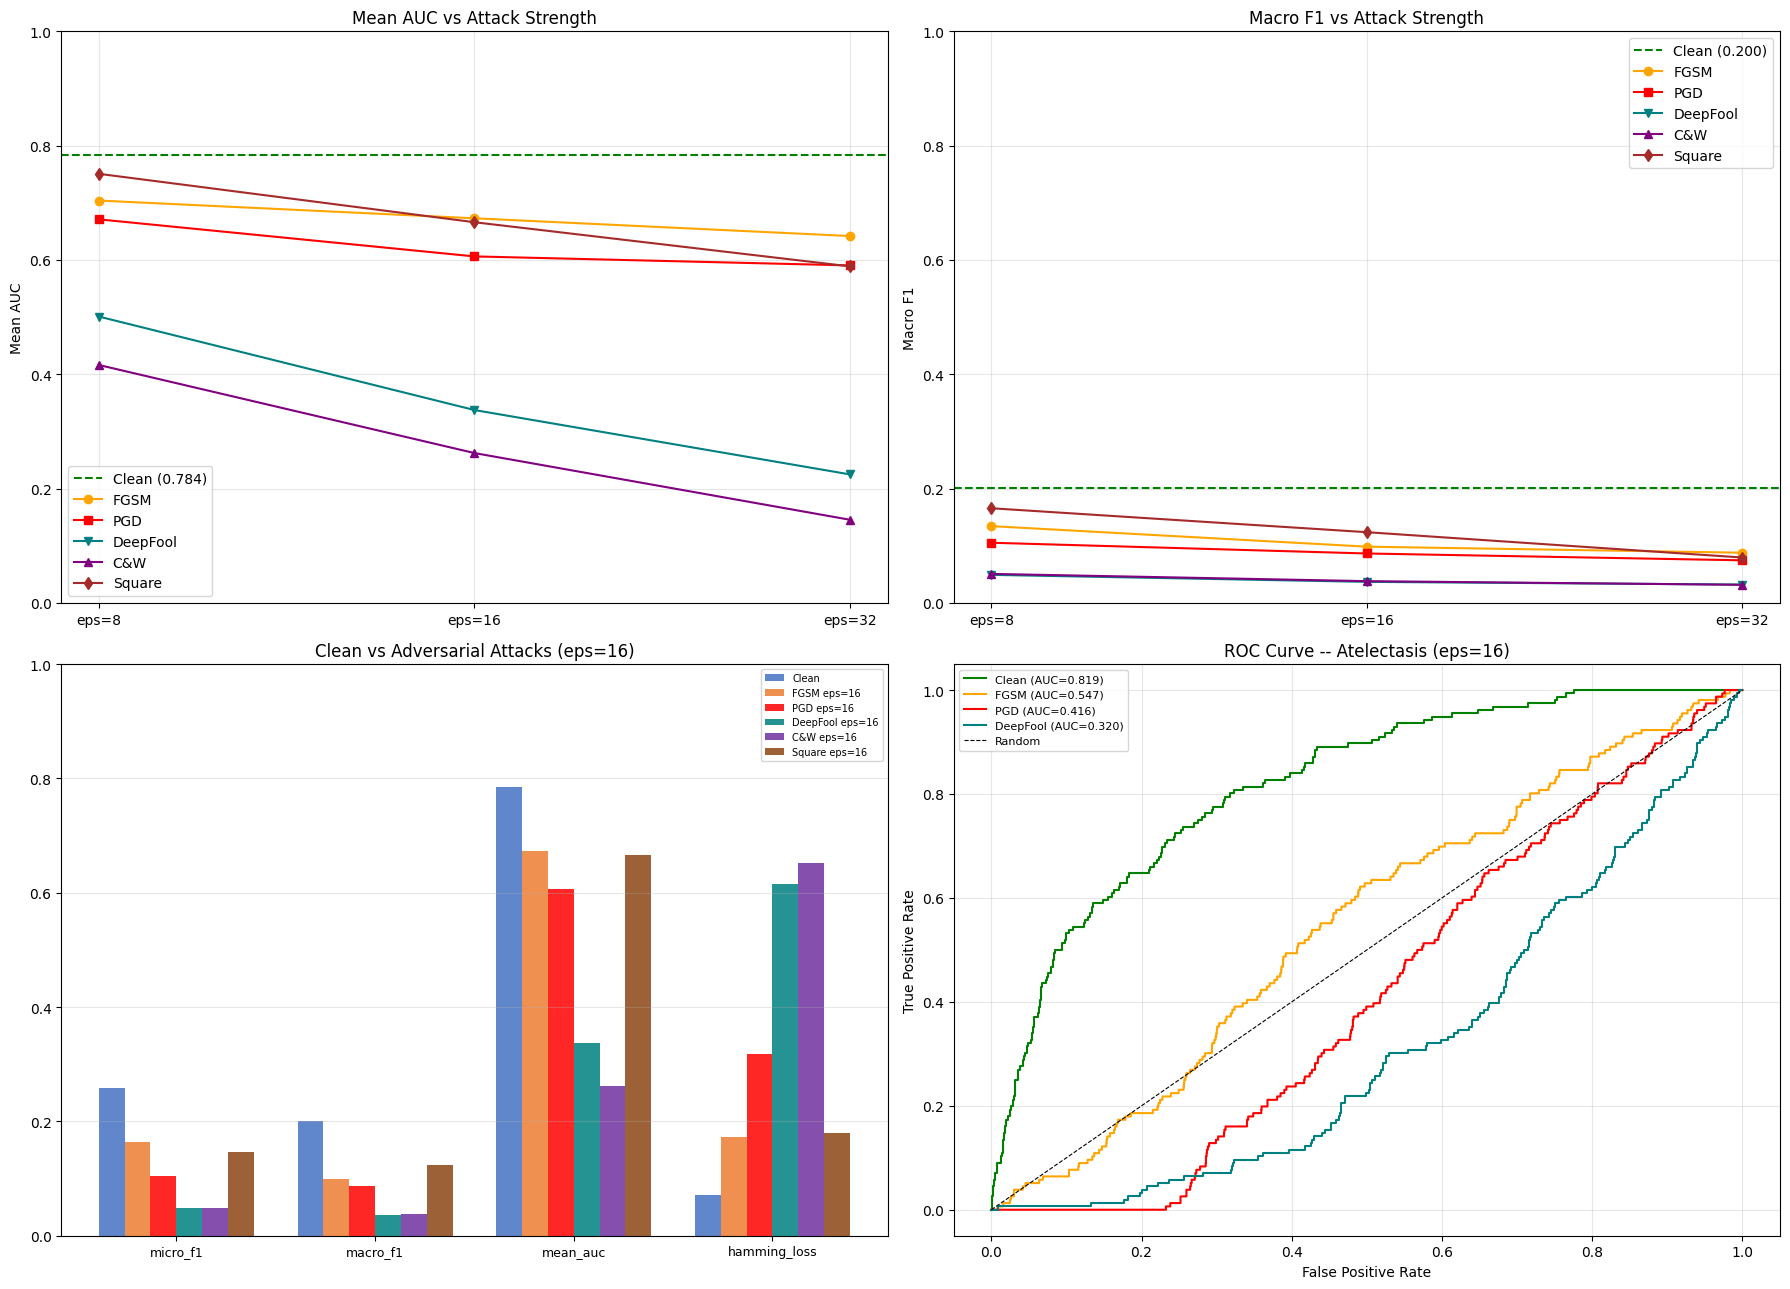

Saved all_attacks_results.png


In [29]:
# Cell F (UPDATED): Plots -- FGSM, PGD, DeepFool, C&W, Square, per-class thresholds
from sklearn.metrics import roc_curve

fgsm_aggs, pgd_aggs, df_aggs, cw_aggs, sq_aggs = {}, {}, {}, {}, {}
for eps in epsilons:
    _, fgsm_aggs[eps] = compute_full_metrics(fgsm_all_probs[eps], fgsm_all_labels, dataset.pathologies, threshold=per_class_thresh)
    _, pgd_aggs[eps]  = compute_full_metrics(pgd_all_probs[eps],  pgd_all_labels,  dataset.pathologies, threshold=per_class_thresh)
    _, df_aggs[eps]   = compute_full_metrics(deepfool_all_probs[eps], deepfool_all_labels, dataset.pathologies, threshold=per_class_thresh)
    _, cw_aggs[eps]   = compute_full_metrics(cw_all_probs[eps],   cw_all_labels,   dataset.pathologies, threshold=per_class_thresh)
    _, sq_aggs[eps]   = compute_full_metrics(sq_all_probs[eps],   sq_all_labels,   dataset.pathologies, threshold=per_class_thresh)

eps_labels = [f"eps={e:.0f}" for e in epsilons]
mid_eps = epsilons[1]

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

axes[0,0].axhline(ft_agg_v2["mean_auc"], color="green", linestyle="--", label=f"Clean ({ft_agg_v2['mean_auc']:.3f})")
axes[0,0].plot(eps_labels, [fgsm_aggs[e]["mean_auc"] for e in epsilons], "o-", color="orange", label="FGSM")
axes[0,0].plot(eps_labels, [pgd_aggs[e]["mean_auc"]  for e in epsilons], "s-", color="red",    label="PGD")
axes[0,0].plot(eps_labels, [df_aggs[e]["mean_auc"]   for e in epsilons], "v-", color="teal",   label="DeepFool")
axes[0,0].plot(eps_labels, [cw_aggs[e]["mean_auc"]   for e in epsilons], "^-", color="purple", label="C&W")
axes[0,0].plot(eps_labels, [sq_aggs[e]["mean_auc"]   for e in epsilons], "d-", color="brown",  label="Square")
axes[0,0].set_ylabel("Mean AUC"); axes[0,0].set_title("Mean AUC vs Attack Strength")
axes[0,0].legend(); axes[0,0].set_ylim(0,1); axes[0,0].grid(alpha=0.3)

axes[0,1].axhline(ft_agg_v2["macro_f1"], color="green", linestyle="--", label=f"Clean ({ft_agg_v2['macro_f1']:.3f})")
axes[0,1].plot(eps_labels, [fgsm_aggs[e]["macro_f1"] for e in epsilons], "o-", color="orange", label="FGSM")
axes[0,1].plot(eps_labels, [pgd_aggs[e]["macro_f1"]  for e in epsilons], "s-", color="red",    label="PGD")
axes[0,1].plot(eps_labels, [df_aggs[e]["macro_f1"]   for e in epsilons], "v-", color="teal",   label="DeepFool")
axes[0,1].plot(eps_labels, [cw_aggs[e]["macro_f1"]   for e in epsilons], "^-", color="purple", label="C&W")
axes[0,1].plot(eps_labels, [sq_aggs[e]["macro_f1"]   for e in epsilons], "d-", color="brown",  label="Square")
axes[0,1].set_ylabel("Macro F1"); axes[0,1].set_title("Macro F1 vs Attack Strength")
axes[0,1].legend(); axes[0,1].set_ylim(0,1); axes[0,1].grid(alpha=0.3)

categories = ["micro_f1", "macro_f1", "mean_auc", "hamming_loss"]
x = np.arange(len(categories)); width = 0.13
clean_vals = [ft_agg_v2[c] for c in categories]
fgsm_vals  = [fgsm_aggs[mid_eps][c] for c in categories]
pgd_vals   = [pgd_aggs[mid_eps][c]  for c in categories]
df_vals    = [df_aggs[mid_eps][c]   for c in categories]
cw_vals    = [cw_aggs[mid_eps][c]   for c in categories]
sq_vals    = [sq_aggs[mid_eps][c]   for c in categories]

axes[1,0].bar(x-2.5*width, clean_vals, width, label="Clean", color="#4472C4", alpha=0.85)
axes[1,0].bar(x-1.5*width, fgsm_vals,  width, label=f"FGSM eps={mid_eps:.0f}", color="#ED7D31", alpha=0.85)
axes[1,0].bar(x-0.5*width, pgd_vals,   width, label=f"PGD eps={mid_eps:.0f}",  color="#FF0000", alpha=0.85)
axes[1,0].bar(x+0.5*width, df_vals,    width, label=f"DeepFool eps={mid_eps:.0f}", color="#008080", alpha=0.85)
axes[1,0].bar(x+1.5*width, cw_vals,    width, label=f"C&W eps={mid_eps:.0f}",  color="#7030A0", alpha=0.85)
axes[1,0].bar(x+2.5*width, sq_vals,    width, label=f"Square eps={mid_eps:.0f}", color="#8B4513", alpha=0.85)
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(categories, fontsize=9)
axes[1,0].set_title(f"Clean vs Adversarial Attacks (eps={mid_eps:.0f})")
axes[1,0].legend(fontsize=7); axes[1,0].set_ylim(0,1); axes[1,0].grid(alpha=0.3, axis="y")

eps_plot = epsilons[1]
d_idx = list(dataset.pathologies).index("Atelectasis")
n = min(len(fgsm_all_labels), len(pgd_all_labels), len(deepfool_all_labels))

def get_roc(labels, probs, idx):
    l = labels[:n, idx]; p = probs[:n, idx]
    valid = ~np.isnan(l)
    fpr, tpr, _ = roc_curve(l[valid].astype(int), p[valid])
    auc = roc_auc_score(l[valid].astype(int), p[valid])
    return fpr, tpr, auc

fpr_c, tpr_c, auc_c = get_roc(ft_labels, ft_probs, d_idx)
fpr_f, tpr_f, auc_f = get_roc(fgsm_all_labels, fgsm_all_probs[eps_plot], d_idx)
fpr_p, tpr_p, auc_p = get_roc(pgd_all_labels, pgd_all_probs[eps_plot], d_idx)
fpr_df, tpr_df, auc_df = get_roc(deepfool_all_labels, deepfool_all_probs[eps_plot], d_idx)

axes[1,1].plot(fpr_c, tpr_c, color="green",  label=f"Clean (AUC={auc_c:.3f})")
axes[1,1].plot(fpr_f, tpr_f, color="orange", label=f"FGSM (AUC={auc_f:.3f})")
axes[1,1].plot(fpr_p, tpr_p, color="red",    label=f"PGD (AUC={auc_p:.3f})")
axes[1,1].plot(fpr_df, tpr_df, color="teal", label=f"DeepFool (AUC={auc_df:.3f})")
axes[1,1].plot([0,1],[0,1],"k--",linewidth=0.8,label="Random")
axes[1,1].set_xlabel("False Positive Rate"); axes[1,1].set_ylabel("True Positive Rate")
axes[1,1].set_title(f"ROC Curve -- Atelectasis (eps={eps_plot:.0f})")
axes[1,1].legend(fontsize=8); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("all_attacks_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved all_attacks_results.png")

## Person B — CLAHE defense, adversarial training, final comparison, Gradio demo

In [30]:
# Cell B0: CLAHE diagnostic -- clean images only, no attack.
# This isolates whether CLAHE itself (distribution shift) hurts performance,
# separate from anything to do with the attacks.
# apply_clahe_batch is now defined earlier (moved up before the Attacks
# section) so the FGSM/PGD/DeepFool loops there can reuse it -- see the note
# on that cell for why.

clahe_clean_probs, clahe_clean_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        images = apply_clahe_batch(batch["img"].to(device))
        clahe_clean_probs.append(torch.sigmoid(align_logits(model(images))).cpu().numpy())
        clahe_clean_labels.append(batch["lab"].numpy())
clahe_clean_probs  = np.concatenate(clahe_clean_probs, axis=0)
clahe_clean_labels = np.concatenate(clahe_clean_labels, axis=0).astype(float)
clahe_clean_labels[clahe_clean_labels == -1] = np.nan

print("CLAHE diagnostic -- clean images, no attack:")
print_metric_row("Clean (no CLAHE)", ft_probs, ft_labels, per_class_thresh)
print_metric_row("Clean + CLAHE only (no attack)", clahe_clean_probs, clahe_clean_labels, per_class_thresh)

CLAHE diagnostic -- clean images, no attack:
Clean (no CLAHE)                0.2592    0.2004    0.7842    0.0717
Clean + CLAHE only (no attack)    0.1751    0.1038    0.6706    0.0816


In [31]:
# Cell B1: CLAHE defense (Level 1)
def run_attack_with_clahe(attack_fn, attack_name, loader):
    probs_by_eps, labels_all = {eps: [] for eps in epsilons}, []
    print(f"Running {attack_name} + CLAHE...")
    for i, batch in enumerate(loader):
        images          = batch["img"].to(device)
        labels          = batch["lab"]
        class_labels    = labels.argmax(dim=1).to(device)
        labels_multihot = labels.to(device)

        # FGSM/PGD (foolbox, single-label) get class_labels; the three
        # multi-label-aware attacks get the full label vector.
        multilabel_attacks = (LinfSquareAttack, MultiLabelDeepFool, MultiLabelCW)
        label_arg = labels_multihot if isinstance(attack_fn, multilabel_attacks) else class_labels

        _, clipped, _ = attack_fn(fmodel, images, label_arg, epsilons=epsilons)
        labels_all.append(labels.numpy())
        for j, eps in enumerate(epsilons):
            defended = apply_clahe_batch(clipped[j])
            with torch.no_grad():
                raw_probs = torch.sigmoid(align_logits(model(defended))).cpu().numpy()
            probs_by_eps[eps].append(raw_probs)
        if i % 10 == 0:
            print(f"  Batch {i}/{len(loader)}")
    labels_all = np.concatenate(labels_all, axis=0).astype(float)
    labels_all[labels_all == -1] = np.nan
    for eps in epsilons:
        probs_by_eps[eps] = np.concatenate(probs_by_eps[eps], axis=0)
    print(f"{attack_name} + CLAHE done.")
    return probs_by_eps, labels_all

# OPT: FGSM/PGD/DeepFool + CLAHE were already computed together with the
# baseline (no-CLAHE) attack back in the Attacks section (same fine-tuned
# model, same crafted adversarial images -- CLAHE is just post-processing on
# top). clahe_fgsm_probs/clahe_pgd_probs/clahe_df_probs (and their _labels)
# already exist from those cells -- reused directly here instead of
# re-running these three attacks against the full test set a second time.
assert all(name in globals() for name in
           ["clahe_fgsm_probs", "clahe_pgd_probs", "clahe_df_probs"]), \
    "clahe_fgsm_probs/clahe_pgd_probs/clahe_df_probs missing -- make sure the FGSM/PGD/DeepFool cells in the Attacks section ran first."
print("FGSM/PGD/DeepFool + CLAHE already computed in the Attacks section above -- reusing.")

# OPT: C&W and Square Attack are by far the most expensive attacks here (100
# Adam steps / up to 300 queries per image). Both were already run against
# this exact fine-tuned `model` two cells ago, and CLAHE is just a post-hoc
# preprocessing step on top of the same weights -- so instead of calling
# run_attack_with_clahe() and recrafting both attacks from scratch a second
# time, reuse the cached adversarial images (cw_adv_images / sq_adv_images)
# and only pay for the CLAHE + forward pass.
def clahe_eval_from_cache(adv_images_by_eps, attack_name, batch_size=16):
    print(f"Applying CLAHE to cached {attack_name} adversarial images "
          f"(attack itself already computed above -- not re-running it)...")
    probs_by_eps = {}
    for eps in epsilons:
        adv = adv_images_by_eps[eps]
        batch_probs = []
        for start in range(0, adv.shape[0], batch_size):
            batch_imgs = adv[start:start + batch_size].to(device)
            defended = apply_clahe_batch(batch_imgs)
            with torch.no_grad():
                batch_probs.append(torch.sigmoid(align_logits(model(defended))).cpu().numpy())
        probs_by_eps[eps] = np.concatenate(batch_probs, axis=0)
    print(f"{attack_name} + CLAHE done (reused cached attack).")
    return probs_by_eps

clahe_cw_probs, clahe_cw_labels = clahe_eval_from_cache(cw_adv_images, "C&W"), cw_all_labels
clahe_sq_probs, clahe_sq_labels = clahe_eval_from_cache(sq_adv_images, "Square"), sq_all_labels

FGSM/PGD/DeepFool + CLAHE already computed in the Attacks section above -- reusing.
Applying CLAHE to cached C&W adversarial images (attack itself already computed above -- not re-running it)...
C&W + CLAHE done (reused cached attack).
Applying CLAHE to cached Square adversarial images (attack itself already computed above -- not re-running it)...
Square + CLAHE done (reused cached attack).


In [42]:
import csv

def save_attack_csv(path, rows):
    with open(path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["Setting", "Micro F1", "Macro F1", "Mean AUC", "Hamming Loss"])
        for label, probs, labels, thresh in rows:
            _, agg = compute_full_metrics(probs, labels, dataset.pathologies, threshold=thresh)
            writer.writerow([label, round(agg["micro_f1"], 4), round(agg["macro_f1"], 4),
                             round(agg["mean_auc"], 4), round(agg["hamming_loss"], 4)])

ft_rows = [("Clean", ft_probs, ft_labels, per_class_thresh)]
for eps in epsilons: ft_rows.append((f"FGSM eps={int(eps)}", fgsm_all_probs[eps], fgsm_all_labels, per_class_thresh))
for eps in epsilons: ft_rows.append((f"PGD eps={int(eps)}", pgd_all_probs[eps], pgd_all_labels, per_class_thresh))
for eps in epsilons: ft_rows.append((f"DeepFool eps={int(eps)}", deepfool_all_probs[eps], deepfool_all_labels, per_class_thresh))
for eps in epsilons: ft_rows.append((f"C&W eps={int(eps)}", cw_all_probs[eps], cw_all_labels, per_class_thresh))
for eps in epsilons: ft_rows.append((f"Square eps={int(eps)}", sq_all_probs[eps], sq_all_labels, per_class_thresh))
# Level 1: CLAHE-only defense on the same fine-tuned model
ft_rows.append(("CLAHE only -- Clean", clahe_clean_probs, clahe_clean_labels, per_class_thresh))
for eps in epsilons: ft_rows.append((f"CLAHE vs FGSM eps={int(eps)}", clahe_fgsm_probs[eps], clahe_fgsm_labels, per_class_thresh))
for eps in epsilons: ft_rows.append((f"CLAHE vs PGD eps={int(eps)}", clahe_pgd_probs[eps], clahe_pgd_labels, per_class_thresh))
for eps in epsilons: ft_rows.append((f"CLAHE vs DeepFool eps={int(eps)}", clahe_df_probs[eps], clahe_df_labels, per_class_thresh))
for eps in epsilons: ft_rows.append((f"CLAHE vs C&W eps={int(eps)}", clahe_cw_probs[eps], clahe_cw_labels, per_class_thresh))
for eps in epsilons: ft_rows.append((f"CLAHE vs Square eps={int(eps)}", clahe_sq_probs[eps], clahe_sq_labels, per_class_thresh))

save_attack_csv("finetuned_attacks_results.csv", ft_rows)
print("Saved finetuned_attacks_results.csv")

Saved finetuned_attacks_results.csv


In [32]:
# Cell B2: Adversarial training (Level 2) -- 2 clean : 1 FGSM : 1 PGD per batch
robust_model_path = "/home/working/densenet121_robust.pth"

# ---- CHECKPOINT: skip training entirely if weights already exist ----
FORCE_RETRAIN_ROBUST = False

if os.path.exists(robust_model_path) and not FORCE_RETRAIN_ROBUST:
    print(f"Found existing checkpoint: {robust_model_path} -- loading it and skipping training.")
    print("(set FORCE_RETRAIN_ROBUST = True above to force a fresh training run)")
    model.load_state_dict(torch.load(robust_model_path))
    model.eval()
else:
    print("No checkpoint found (or FORCE_RETRAIN_ROBUST=True) -- starting adversarial training...")
    model.load_state_dict(torch.load(best_model_path))  # start from the fixed fine-tuned weights

    criterion_robust = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer_robust = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-5)

    adv_train_attack_fgsm = fb.attacks.FGSM()
    adv_train_attack_pgd  = fb.attacks.LinfPGD(steps=10, abs_stepsize=2.0)
    train_eps = 8.0

    ADV_EPOCHS = 10
    best_val_loss_robust = float("inf")

    print("Starting adversarial training (2 clean : 1 FGSM : 1 PGD per batch)...")
    print("="*70)

    for epoch in range(ADV_EPOCHS):
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            images = batch["img"].to(device)
            labels = batch["lab"].to(device)
            labels_clean = labels.clone().float()
            labels_clean[torch.isnan(labels_clean)] = 0.0
            labels_clean[labels_clean == -1] = 0.0
            class_labels = labels.argmax(dim=1).to(device)

            n = images.shape[0]
            n_clean, n_fgsm = n // 2, n // 4
            clean_imgs = images[:n_clean]
            fgsm_src, fgsm_tgt = images[n_clean:n_clean+n_fgsm], class_labels[n_clean:n_clean+n_fgsm]
            pgd_src,  pgd_tgt  = images[n_clean+n_fgsm:],        class_labels[n_clean+n_fgsm:]

            model.eval()
            fmodel_train = fb.PyTorchModel(model, bounds=(-1024, 1024))
            with torch.enable_grad():
                fgsm_adv = adv_train_attack_fgsm(fmodel_train, fgsm_src, fgsm_tgt, epsilons=train_eps)[1] if fgsm_src.shape[0] else fgsm_src
                pgd_adv  = adv_train_attack_pgd(fmodel_train, pgd_src, pgd_tgt, epsilons=train_eps)[1]  if pgd_src.shape[0]  else pgd_src
            model.train()

            combined_imgs = torch.cat([clean_imgs, fgsm_adv, pgd_adv], dim=0)

            optimizer_robust.zero_grad()
            logits = model(combined_imgs)
            logits_aligned = align_logits(logits)
            loss = criterion_robust(logits_aligned, labels_clean)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer_robust.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                images = batch["img"].to(device)
                labels = batch["lab"].to(device)
                labels_clean = labels.clone().float()
                labels_clean[torch.isnan(labels_clean)] = 0.0
                labels_clean[labels_clean == -1] = 0.0
                logits = model(images)
                val_running_loss += criterion_robust(align_logits(logits), labels_clean).item()
        val_loss = val_running_loss / len(val_loader)

        marker = ""
        if val_loss < best_val_loss_robust:
            best_val_loss_robust = val_loss
            torch.save(model.state_dict(), robust_model_path)
            marker = " <- saved best"

        print(f"Epoch {epoch+1:02d}/{ADV_EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}{marker}")

    print("="*70)
    print(f"Adversarial training done. Robust weights saved to {robust_model_path}")

    # reload the BEST checkpoint before moving on
    model.load_state_dict(torch.load(robust_model_path))
    model.eval()

No checkpoint found (or FORCE_RETRAIN_ROBUST=True) -- starting adversarial training...
Starting adversarial training (2 clean : 1 FGSM : 1 PGD per batch)...
Epoch 01/10  train_loss=0.9785  val_loss=0.9795 <- saved best
Epoch 02/10  train_loss=0.9758  val_loss=0.9780 <- saved best
Epoch 03/10  train_loss=0.9746  val_loss=0.9787
Epoch 04/10  train_loss=0.9726  val_loss=0.9795
Epoch 05/10  train_loss=0.9720  val_loss=0.9788
Epoch 06/10  train_loss=0.9704  val_loss=0.9783
Epoch 07/10  train_loss=0.9695  val_loss=0.9776 <- saved best
Epoch 08/10  train_loss=0.9691  val_loss=0.9780
Epoch 09/10  train_loss=0.9685  val_loss=0.9779
Epoch 10/10  train_loss=0.9680  val_loss=0.9770 <- saved best
Adversarial training done. Robust weights saved to /home/working/densenet121_robust.pth


### Combined defense — CLAHE + Adversarial Training

Level 1 and Level 2 aren't mutually exclusive: CLAHE is a preprocessing step,
adversarial training changes the model weights — nothing stops you from doing
both. This reruns each attack, applies CLAHE to the perturbed image, *then*
feeds it into the adversarially-trained (robust) model. This is the strongest
setting in the notebook and gives you a genuine three-way comparison: CLAHE
alone (fine-tuned model), adversarial training alone (robust model, no
preprocessing), and both together.

In [33]:
# Cell B2c: Combined defense -- CLAHE preprocessing + adversarially-trained model
# model is already the robust checkpoint at this point (loaded at the end of Cell B2)

# OPT: FGSM/PGD/DeepFool get crafted against this exact robust `model` here
# for the "Combined" (CLAHE-defended) row, AND again later in Cell B3 for the
# "Adversarial Training only" (no-CLAHE) row -- same weights, only the
# post-processing differs. Fused into one pass per attack so each is only
# crafted once against the robust model, producing both variants together.
# Cell B3 reuses robust_fgsm_probs/robust_pgd_probs/robust_df_probs computed
# here instead of recrafting. (C&W/Square below are left as separate calls --
# they run on the smaller 300-image subset, so a second crafting pass there
# is much cheaper and out of scope for this fuse.)
def run_attack_combined_and_robust(attack_fn, attack_name, loader):
    combined_probs_by_eps = {eps: [] for eps in epsilons}
    robust_probs_by_eps   = {eps: [] for eps in epsilons}
    labels_all = []
    multilabel_attacks = (LinfSquareAttack, MultiLabelDeepFool, MultiLabelCW)
    print(f"Running {attack_name} (robust model -- combined + adv-training-only variants together)...")
    for i, batch in enumerate(loader):
        images          = batch["img"].to(device)
        labels          = batch["lab"]
        class_labels    = labels.argmax(dim=1).to(device)
        labels_multihot = labels.to(device)
        label_arg = labels_multihot if isinstance(attack_fn, multilabel_attacks) else class_labels

        _, clipped, _ = attack_fn(fmodel, images, label_arg, epsilons=epsilons)
        labels_all.append(labels.numpy())
        for j, eps in enumerate(epsilons):
            with torch.no_grad():
                raw_probs = torch.sigmoid(align_logits(model(clipped[j]))).cpu().numpy()
            robust_probs_by_eps[eps].append(raw_probs)

            defended = apply_clahe_batch(clipped[j])
            with torch.no_grad():
                clahe_probs = torch.sigmoid(align_logits(model(defended))).cpu().numpy()
            combined_probs_by_eps[eps].append(clahe_probs)
        if i % 10 == 0:
            print(f"  Batch {i}/{len(loader)}")
    labels_all = np.concatenate(labels_all, axis=0).astype(float)
    labels_all[labels_all == -1] = np.nan
    for eps in epsilons:
        combined_probs_by_eps[eps] = np.concatenate(combined_probs_by_eps[eps], axis=0)
        robust_probs_by_eps[eps]   = np.concatenate(robust_probs_by_eps[eps], axis=0)
    print(f"{attack_name} done.")
    return combined_probs_by_eps, robust_probs_by_eps, labels_all

combined_fgsm_probs, robust_fgsm_probs, combined_fgsm_labels = run_attack_combined_and_robust(fgsm_attack, "FGSM", test_loader)
combined_pgd_probs,  robust_pgd_probs,  combined_pgd_labels  = run_attack_combined_and_robust(pgd_attack,  "PGD",  test_loader)
combined_df_probs,   robust_df_probs,   combined_df_labels   = run_attack_combined_and_robust(deepfool_attack, "DeepFool", test_loader)
robust_fgsm_labels = combined_fgsm_labels
robust_pgd_labels  = combined_pgd_labels
robust_df_labels   = combined_df_labels

combined_cw_probs,   combined_cw_labels   = run_attack_with_clahe(cw_attack,  "C&W (Combined)",   attack_eval_loader)
combined_sq_probs,   combined_sq_labels   = run_attack_with_clahe(sq_attack,  "Square (Combined)", attack_eval_loader)

# Clean performance of the combined setting (robust model + CLAHE on a clean image).
# OPT: this loop and Cell B3's "robust model, clean, no CLAHE" loop both iterate
# the full test_loader through this exact same robust `model` -- they only differ
# in whether CLAHE is applied. Fused into one pass so the loader/model only get
# walked once instead of twice; robust_clean_probs/labels are picked up directly
# by Cell B3 below instead of being recomputed there.
combined_clean_probs, combined_clean_labels = [], []
robust_clean_probs,   robust_clean_labels   = [], []
with torch.no_grad():
    for batch in test_loader:
        images   = batch["img"].to(device)
        defended = apply_clahe_batch(images)
        combined_clean_probs.append(torch.sigmoid(align_logits(model(defended))).cpu().numpy())
        combined_clean_labels.append(batch["lab"].numpy())
        robust_clean_probs.append(torch.sigmoid(align_logits(model(images))).cpu().numpy())
        robust_clean_labels.append(batch["lab"].numpy())
combined_clean_probs  = np.concatenate(combined_clean_probs, axis=0)
combined_clean_labels = np.concatenate(combined_clean_labels, axis=0).astype(float)
combined_clean_labels[combined_clean_labels == -1] = np.nan
combined_threshold = float(combined_clean_probs.mean())

robust_clean_probs  = np.concatenate(robust_clean_probs, axis=0)
robust_clean_labels = np.concatenate(robust_clean_labels, axis=0).astype(float)
robust_clean_labels[robust_clean_labels == -1] = np.nan
robust_threshold = float(robust_clean_probs.mean())

print("Combined defense (CLAHE + adversarial training) evaluated against all 5 attacks.")

Running FGSM (robust model -- combined + adv-training-only variants together)...
  Batch 0/81
  Batch 10/81
  Batch 20/81
  Batch 30/81
  Batch 40/81
  Batch 50/81
  Batch 60/81
  Batch 70/81
  Batch 80/81
FGSM done.
Running PGD (robust model -- combined + adv-training-only variants together)...
  Batch 0/81
  Batch 10/81
  Batch 20/81
  Batch 30/81
  Batch 40/81
  Batch 50/81
  Batch 60/81
  Batch 70/81
  Batch 80/81
PGD done.
Running DeepFool (robust model -- combined + adv-training-only variants together)...
  Batch 0/81
  Batch 10/81
  Batch 20/81
  Batch 30/81
  Batch 40/81
  Batch 50/81
  Batch 60/81
  Batch 70/81
  Batch 80/81
DeepFool done.
Running C&W (Combined) + CLAHE...
  Batch 0/19
  Batch 10/19
C&W (Combined) + CLAHE done.
Running Square (Combined) + CLAHE...
  Batch 0/19
  Batch 10/19
Square (Combined) + CLAHE done.
Combined defense (CLAHE + adversarial training) evaluated against all 5 attacks.


In [34]:
# Combined defense: per-class thresholds calibrated on val set (robust model + CLAHE)
val_probs_combined = []
with torch.no_grad():
    for batch in val_loader:
        images = apply_clahe_batch(batch["img"].to(device))
        val_probs_combined.append(torch.sigmoid(align_logits(model(images))).cpu().numpy())
val_probs_combined = np.concatenate(val_probs_combined, axis=0)
per_class_thresh_combined = compute_per_class_thresholds(val_probs_combined, val_labels_ft, dataset.pathologies, fallback=combined_threshold)

print("-"*70)
print("  -- Combined: CLAHE + Adversarial training together --")
print_metric_row("Combined -- Clean", combined_clean_probs, combined_clean_labels, per_class_thresh_combined)
for eps in epsilons: print_metric_row(f"Combined vs FGSM eps={int(eps)}", combined_fgsm_probs[eps], combined_fgsm_labels, per_class_thresh_combined)
for eps in epsilons: print_metric_row(f"Combined vs PGD eps={int(eps)}",  combined_pgd_probs[eps],  combined_pgd_labels,  per_class_thresh_combined)
for eps in epsilons: print_metric_row(f"Combined vs DeepFool eps={int(eps)}", combined_df_probs[eps], combined_df_labels, per_class_thresh_combined)
for eps in epsilons: print_metric_row(f"Combined vs C&W eps={int(eps)}",  combined_cw_probs[eps],   combined_cw_labels,   per_class_thresh_combined)
for eps in epsilons: print_metric_row(f"Combined vs Square eps={int(eps)}", combined_sq_probs[eps], combined_sq_labels, per_class_thresh_combined)
print("="*70)

----------------------------------------------------------------------
  -- Combined: CLAHE + Adversarial training together --
Combined -- Clean               0.1375    0.1197    0.6631    0.1552
Combined vs FGSM eps=8          0.1558    0.1262    0.6829    0.1398
Combined vs FGSM eps=16         0.1631    0.1227    0.6659    0.1293
Combined vs FGSM eps=32         0.1441    0.0856    0.6166    0.1035
Combined vs PGD eps=8           0.1486    0.1218    0.6657    0.1581
Combined vs PGD eps=16          0.1410    0.1022    0.6601    0.1707
Combined vs PGD eps=32          0.1377    0.0916    0.6515    0.1690
Combined vs DeepFool eps=8      0.1111    0.0889    0.6154    0.2180
Combined vs DeepFool eps=16     0.0809    0.0631    0.5396    0.2843
Combined vs DeepFool eps=32     0.0647    0.0421    0.4793    0.2799
Combined vs C&W eps=8           0.1173    0.0938    0.6067    0.2329
Combined vs C&W eps=16          0.0888    0.0746    0.5357    0.3029
Combined vs C&W eps=32          0.0679    0.0

In [35]:
# Cell B3: Full final comparison table, incl. per-model per-class thresholds
def score_model_on_attack(attack_fn, loader, use_model):
    probs_by_eps, labels_all = {eps: [] for eps in epsilons}, []
    multilabel_attacks = (LinfSquareAttack, MultiLabelDeepFool, MultiLabelCW)
    for batch in loader:
        images          = batch["img"].to(device)
        labels          = batch["lab"]
        class_labels    = labels.argmax(dim=1).to(device)
        labels_multihot = labels.to(device)
        label_arg = labels_multihot if isinstance(attack_fn, multilabel_attacks) else class_labels
        _, clipped, _ = attack_fn(fmodel, images, label_arg, epsilons=epsilons)
        labels_all.append(labels.numpy())
        for j, eps in enumerate(epsilons):
            with torch.no_grad():
                raw_probs = torch.sigmoid(align_logits(use_model(clipped[j]))).cpu().numpy()
            probs_by_eps[eps].append(raw_probs)
    labels_all = np.concatenate(labels_all, axis=0).astype(float)
    labels_all[labels_all == -1] = np.nan
    for eps in epsilons:
        probs_by_eps[eps] = np.concatenate(probs_by_eps[eps], axis=0)
    return probs_by_eps, labels_all

# OPT: FGSM/PGD/DeepFool against the robust model were already computed in
# Cell B2c above -- fused together with the "Combined" (CLAHE-defended)
# variant, since both target this exact robust `model` and only differ in
# whether CLAHE is applied afterward. Reused directly here instead of
# recrafting these three attacks against the full test set a second time.
assert all(name in globals() for name in
           ["robust_fgsm_probs", "robust_pgd_probs", "robust_df_probs"]), \
    "robust_fgsm_probs/robust_pgd_probs/robust_df_probs missing -- make sure Cell B2c ran before this cell."

# C&W and Square Attack ARE still recrafted here (not fused, unlike the three
# above) -- they run on the much smaller 300-image subset, so a second
# crafting pass is cheap, and fusing them would mean changing Cell B2c's
# C&W/Square path too, which is out of scope for this optimization pass.
robust_cw_probs, robust_cw_labels = score_model_on_attack(cw_attack, attack_eval_loader, model)
robust_sq_probs, robust_sq_labels = score_model_on_attack(sq_attack, attack_eval_loader, model)

# OPT: robust_clean_probs/robust_clean_labels/robust_threshold are already
# computed in Cell B2c (fused into the same test_loader pass as
# combined_clean_probs, since both walk the full test set through this exact
# robust `model` and only differ in whether CLAHE is applied). Reused directly
# here instead of walking the test set through the model a second time.
assert "robust_clean_probs" in globals(), \
    "robust_clean_probs missing -- make sure Cell B2c ran before this cell."

# Per-class thresholds for the robust model, calibrated on val set
val_probs_robust = []
with torch.no_grad():
    for batch in val_loader:
        images = batch["img"].to(device)
        val_probs_robust.append(torch.sigmoid(align_logits(model(images))).cpu().numpy())
val_probs_robust = np.concatenate(val_probs_robust, axis=0)
per_class_thresh_robust = compute_per_class_thresholds(val_probs_robust, val_labels_ft, dataset.pathologies, fallback=robust_threshold)

print("="*70)
print(f"{'Setting':<32} {'Mean AUC':>9} {'Macro F1':>9} {'Hamming':>9}")
print("-"*70)
print_metric_row("Fine-tuned -- Clean", ft_probs, ft_labels, per_class_thresh)
for eps in epsilons: print_metric_row(f"FT vs FGSM eps={int(eps)}", fgsm_all_probs[eps], fgsm_all_labels, per_class_thresh)
for eps in epsilons: print_metric_row(f"FT vs PGD eps={int(eps)}",  pgd_all_probs[eps],  pgd_all_labels,  per_class_thresh)
for eps in epsilons: print_metric_row(f"FT vs DeepFool eps={int(eps)}", deepfool_all_probs[eps], deepfool_all_labels, per_class_thresh)
for eps in epsilons: print_metric_row(f"FT vs C&W eps={int(eps)}",  cw_all_probs[eps],   cw_all_labels,   per_class_thresh)
for eps in epsilons: print_metric_row(f"FT vs Square eps={int(eps)}", sq_all_probs[eps], sq_all_labels, per_class_thresh)
print("-"*70)
print("  -- Level 1: CLAHE only (fine-tuned model + input preprocessing) --")
for eps in epsilons: print_metric_row(f"CLAHE vs FGSM eps={int(eps)}", clahe_fgsm_probs[eps], clahe_fgsm_labels, per_class_thresh)
for eps in epsilons: print_metric_row(f"CLAHE vs PGD eps={int(eps)}",  clahe_pgd_probs[eps],  clahe_pgd_labels,  per_class_thresh)
for eps in epsilons: print_metric_row(f"CLAHE vs DeepFool eps={int(eps)}", clahe_df_probs[eps], clahe_df_labels, per_class_thresh)
for eps in epsilons: print_metric_row(f"CLAHE vs C&W eps={int(eps)}",  clahe_cw_probs[eps],   clahe_cw_labels,   per_class_thresh)
for eps in epsilons: print_metric_row(f"CLAHE vs Square eps={int(eps)}", clahe_sq_probs[eps], clahe_sq_labels, per_class_thresh)
print("-"*70)
print("  -- Level 2: Adversarial training only (robust model, no CLAHE) --")
print_metric_row("Robust model -- Clean", robust_clean_probs, robust_clean_labels, per_class_thresh_robust)
for eps in epsilons: print_metric_row(f"Robust vs FGSM eps={int(eps)}", robust_fgsm_probs[eps], robust_fgsm_labels, per_class_thresh_robust)
for eps in epsilons: print_metric_row(f"Robust vs PGD eps={int(eps)}",  robust_pgd_probs[eps],  robust_pgd_labels,  per_class_thresh_robust)
for eps in epsilons: print_metric_row(f"Robust vs DeepFool eps={int(eps)}", robust_df_probs[eps], robust_df_labels, per_class_thresh_robust)
for eps in epsilons: print_metric_row(f"Robust vs C&W eps={int(eps)}",  robust_cw_probs[eps],   robust_cw_labels,   per_class_thresh_robust)
for eps in epsilons: print_metric_row(f"Robust vs Square eps={int(eps)}", robust_sq_probs[eps], robust_sq_labels, per_class_thresh_robust)
print("="*70)

Setting                           Mean AUC  Macro F1   Hamming
----------------------------------------------------------------------
Fine-tuned -- Clean             0.2592    0.2004    0.7842    0.0717
FT vs FGSM eps=8                0.1925    0.1345    0.7040    0.1450
FT vs FGSM eps=16               0.1633    0.0985    0.6730    0.1735
FT vs FGSM eps=32               0.1448    0.0880    0.6419    0.1959
FT vs PGD eps=8                 0.1251    0.1054    0.6711    0.2616
FT vs PGD eps=16                0.1045    0.0866    0.6063    0.3176
FT vs PGD eps=32                0.0987    0.0747    0.5905    0.3437
FT vs DeepFool eps=8            0.0644    0.0492    0.5011    0.4764
FT vs DeepFool eps=16           0.0491    0.0370    0.3376    0.6156
FT vs DeepFool eps=32           0.0401    0.0323    0.2249    0.7048
FT vs C&W eps=8                 0.0671    0.0509    0.4164    0.4831
FT vs C&W eps=16                0.0487    0.0382    0.2623    0.6514
FT vs C&W eps=32                0.0371

In [45]:
import csv

robust_per_class, robust_agg = compute_full_metrics(
    robust_clean_probs, robust_clean_labels, dataset.pathologies, threshold=per_class_thresh_robust
)

with open("robust_results.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Disease", "Precision", "Recall", "F1", "AUC", "Threshold"])
    for name, m in robust_per_class.items():
        writer.writerow([name, round(m["Precision"], 4), round(m["Recall"], 4),
                         round(m["F1"], 4), round(m["AUC"], 4), round(per_class_thresh_robust[name], 4)])
    writer.writerow([])
    writer.writerow(["Micro F1", "", "", round(robust_agg["micro_f1"], 4), "", ""])
    writer.writerow(["Macro F1", "", "", round(robust_agg["macro_f1"], 4), "", ""])
    writer.writerow(["Mean AUC", "", "", "", round(robust_agg["mean_auc"], 4), ""])
    writer.writerow(["Hamming Loss", "", "", round(robust_agg["hamming_loss"], 4), "", ""])

print("Saved to robust_results.csv")

Saved to robust_results.csv


In [46]:
robust_rows = [("Robust -- Clean", robust_clean_probs, robust_clean_labels, per_class_thresh_robust)]
for eps in epsilons: robust_rows.append((f"Robust vs FGSM eps={int(eps)}", robust_fgsm_probs[eps], robust_fgsm_labels, per_class_thresh_robust))
for eps in epsilons: robust_rows.append((f"Robust vs PGD eps={int(eps)}", robust_pgd_probs[eps], robust_pgd_labels, per_class_thresh_robust))
for eps in epsilons: robust_rows.append((f"Robust vs DeepFool eps={int(eps)}", robust_df_probs[eps], robust_df_labels, per_class_thresh_robust))
for eps in epsilons: robust_rows.append((f"Robust vs C&W eps={int(eps)}", robust_cw_probs[eps], robust_cw_labels, per_class_thresh_robust))
for eps in epsilons: robust_rows.append((f"Robust vs Square eps={int(eps)}", robust_sq_probs[eps], robust_sq_labels, per_class_thresh_robust))
# Combined: robust model + CLAHE
robust_rows.append(("Combined -- Clean", combined_clean_probs, combined_clean_labels, per_class_thresh_combined))
for eps in epsilons: robust_rows.append((f"Combined vs FGSM eps={int(eps)}", combined_fgsm_probs[eps], combined_fgsm_labels, per_class_thresh_combined))
for eps in epsilons: robust_rows.append((f"Combined vs PGD eps={int(eps)}", combined_pgd_probs[eps], combined_pgd_labels, per_class_thresh_combined))
for eps in epsilons: robust_rows.append((f"Combined vs DeepFool eps={int(eps)}", combined_df_probs[eps], combined_df_labels, per_class_thresh_combined))
for eps in epsilons: robust_rows.append((f"Combined vs C&W eps={int(eps)}", combined_cw_probs[eps], combined_cw_labels, per_class_thresh_combined))
for eps in epsilons: robust_rows.append((f"Combined vs Square eps={int(eps)}", combined_sq_probs[eps], combined_sq_labels, per_class_thresh_combined))

save_attack_csv("robust_attacks_results.csv", robust_rows)
print("Saved robust_attacks_results.csv")

Saved robust_attacks_results.csv


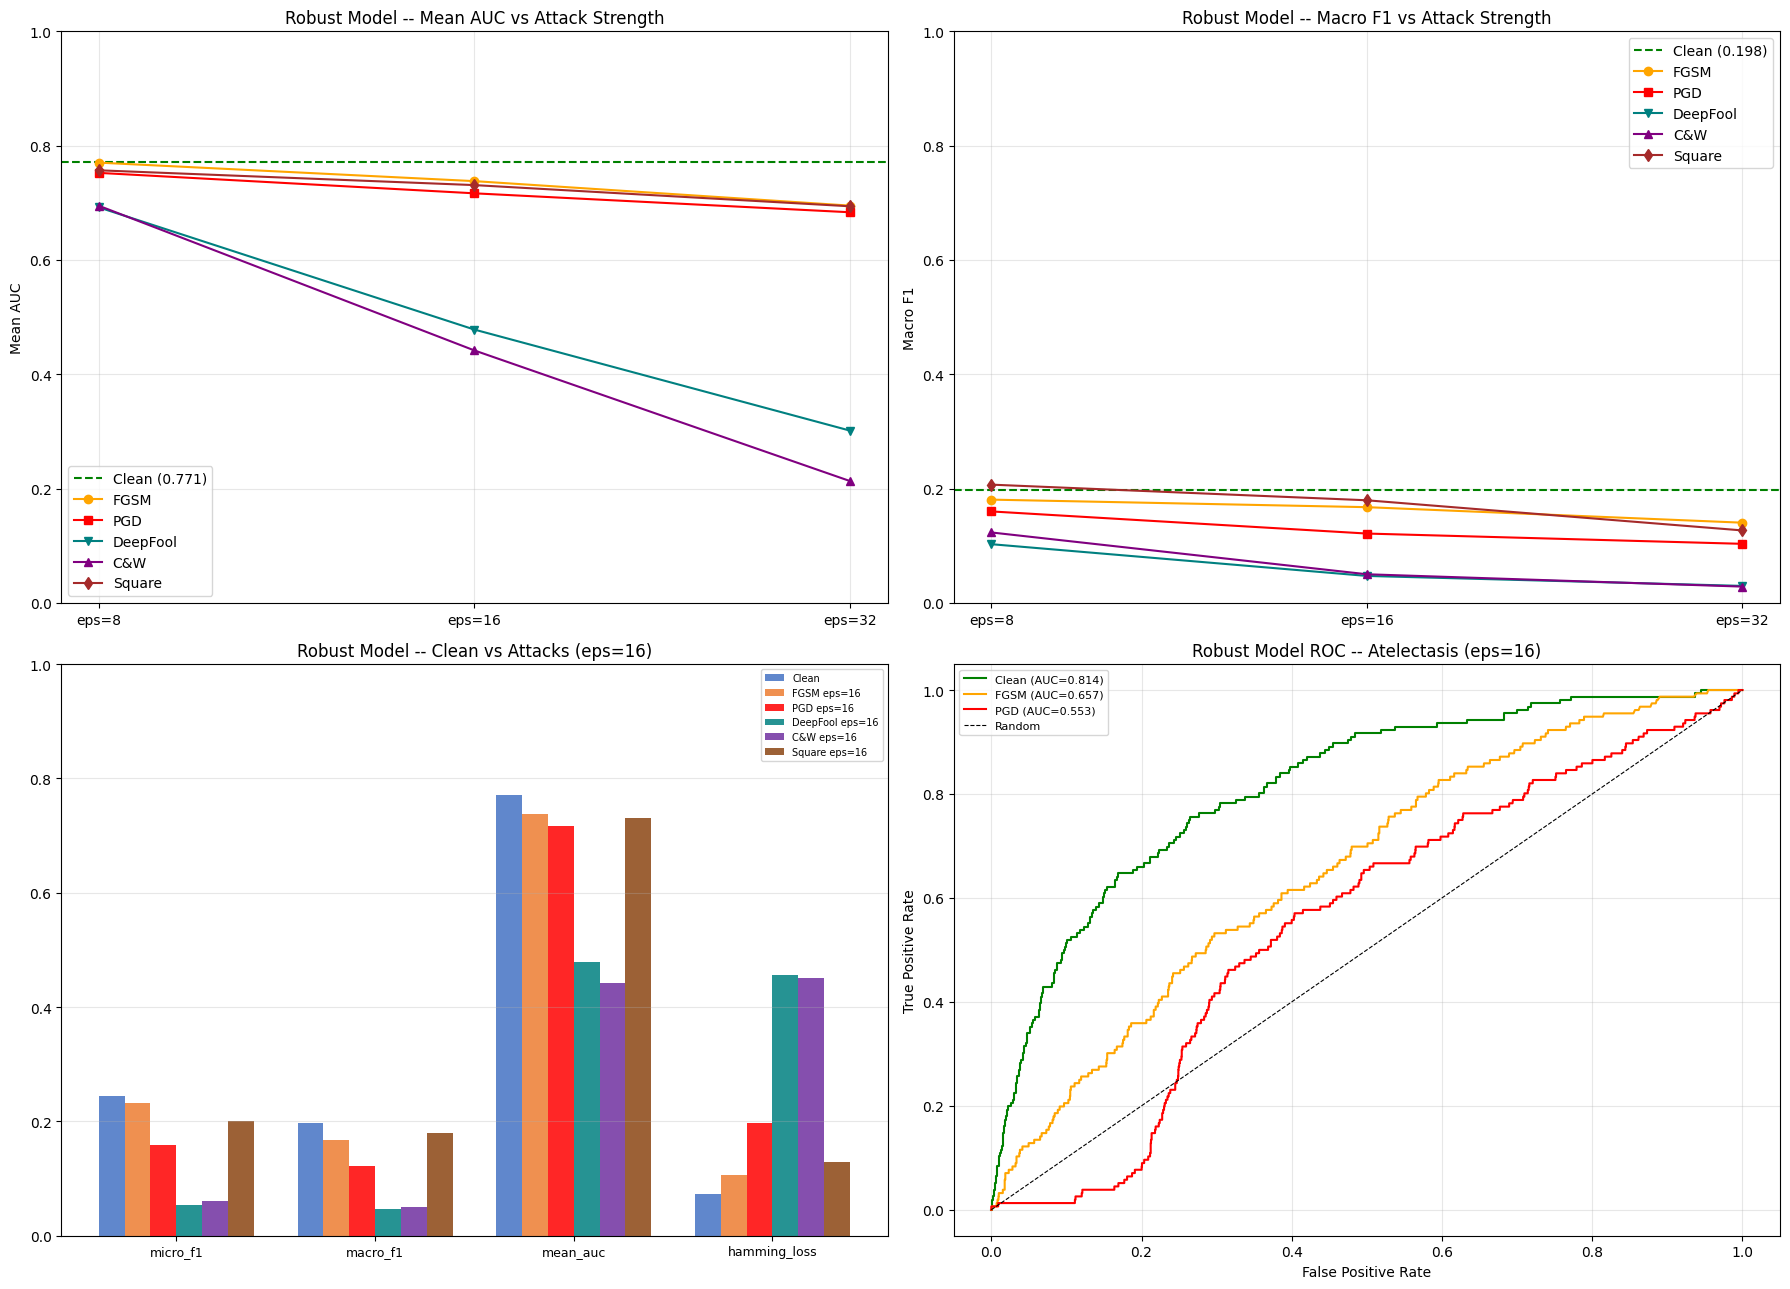

Saved robust_attacks_results.png


In [47]:
robust_aggs = {}
for label, probs, labels in [
    ("FGSM", robust_fgsm_probs, robust_fgsm_labels),
    ("PGD", robust_pgd_probs, robust_pgd_labels),
    ("DeepFool", robust_df_probs, robust_df_labels),
    ("C&W", robust_cw_probs, robust_cw_labels),
    ("Square", robust_sq_probs, robust_sq_labels),
]:
    robust_aggs[label] = {eps: compute_full_metrics(probs[eps], labels, dataset.pathologies, threshold=per_class_thresh_robust)[1] for eps in epsilons}

_, robust_clean_agg = compute_full_metrics(robust_clean_probs, robust_clean_labels, dataset.pathologies, threshold=per_class_thresh_robust)

eps_labels = [f"eps={e:.0f}" for e in epsilons]
mid_eps = epsilons[1]
colors = {"FGSM": "orange", "PGD": "red", "DeepFool": "teal", "C&W": "purple", "Square": "brown"}
markers = {"FGSM": "o", "PGD": "s", "DeepFool": "v", "C&W": "^", "Square": "d"}

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

axes[0,0].axhline(robust_clean_agg["mean_auc"], color="green", linestyle="--", label=f"Clean ({robust_clean_agg['mean_auc']:.3f})")
for name in robust_aggs:
    axes[0,0].plot(eps_labels, [robust_aggs[name][e]["mean_auc"] for e in epsilons], markers[name]+"-", color=colors[name], label=name)
axes[0,0].set_ylabel("Mean AUC"); axes[0,0].set_title("Robust Model -- Mean AUC vs Attack Strength")
axes[0,0].legend(); axes[0,0].set_ylim(0,1); axes[0,0].grid(alpha=0.3)

axes[0,1].axhline(robust_clean_agg["macro_f1"], color="green", linestyle="--", label=f"Clean ({robust_clean_agg['macro_f1']:.3f})")
for name in robust_aggs:
    axes[0,1].plot(eps_labels, [robust_aggs[name][e]["macro_f1"] for e in epsilons], markers[name]+"-", color=colors[name], label=name)
axes[0,1].set_ylabel("Macro F1"); axes[0,1].set_title("Robust Model -- Macro F1 vs Attack Strength")
axes[0,1].legend(); axes[0,1].set_ylim(0,1); axes[0,1].grid(alpha=0.3)

categories = ["micro_f1", "macro_f1", "mean_auc", "hamming_loss"]
x = np.arange(len(categories)); width = 0.13
vals = {"Clean": [robust_clean_agg[c] for c in categories]}
for name in robust_aggs:
    vals[name] = [robust_aggs[name][mid_eps][c] for c in categories]
bar_colors = {"Clean": "#4472C4", "FGSM": "#ED7D31", "PGD": "#FF0000", "DeepFool": "#008080", "C&W": "#7030A0", "Square": "#8B4513"}
for i, (name, v) in enumerate(vals.items()):
    axes[1,0].bar(x + (i-2.5)*width, v, width, label=name if name=="Clean" else f"{name} eps={mid_eps:.0f}", color=bar_colors[name], alpha=0.85)
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(categories, fontsize=9)
axes[1,0].set_title(f"Robust Model -- Clean vs Attacks (eps={mid_eps:.0f})")
axes[1,0].legend(fontsize=7); axes[1,0].set_ylim(0,1); axes[1,0].grid(alpha=0.3, axis="y")

from sklearn.metrics import roc_curve
d_idx = list(dataset.pathologies).index("Atelectasis")
def get_roc(labels, probs, idx):
    l, p = labels[:, idx], probs[:, idx]
    valid = ~np.isnan(l)
    fpr, tpr, _ = roc_curve(l[valid].astype(int), p[valid])
    auc = roc_auc_score(l[valid].astype(int), p[valid])
    return fpr, tpr, auc

fpr_c, tpr_c, auc_c = get_roc(robust_clean_labels, robust_clean_probs, d_idx)
fpr_f, tpr_f, auc_f = get_roc(robust_fgsm_labels, robust_fgsm_probs[mid_eps], d_idx)
fpr_p, tpr_p, auc_p = get_roc(robust_pgd_labels, robust_pgd_probs[mid_eps], d_idx)
axes[1,1].plot(fpr_c, tpr_c, color="green", label=f"Clean (AUC={auc_c:.3f})")
axes[1,1].plot(fpr_f, tpr_f, color="orange", label=f"FGSM (AUC={auc_f:.3f})")
axes[1,1].plot(fpr_p, tpr_p, color="red", label=f"PGD (AUC={auc_p:.3f})")
axes[1,1].plot([0,1],[0,1],"k--",linewidth=0.8,label="Random")
axes[1,1].set_xlabel("False Positive Rate"); axes[1,1].set_ylabel("True Positive Rate")
axes[1,1].set_title(f"Robust Model ROC -- Atelectasis (eps={mid_eps:.0f})")
axes[1,1].legend(fontsize=8); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("robust_attacks_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved robust_attacks_results.png")

Saved extended_attack_metrics.csv
Saved attack_degradation_analysis.csv
Saved defense_comparison.csv
Saved attack_ranking.csv
Saved attack_severity_analysis.csv
Saved per_class_vulnerability.csv
Saved threshold_analysis.csv
Training arrays are empty because the model was loaded from checkpoint. Skipping training_analysis.csv.


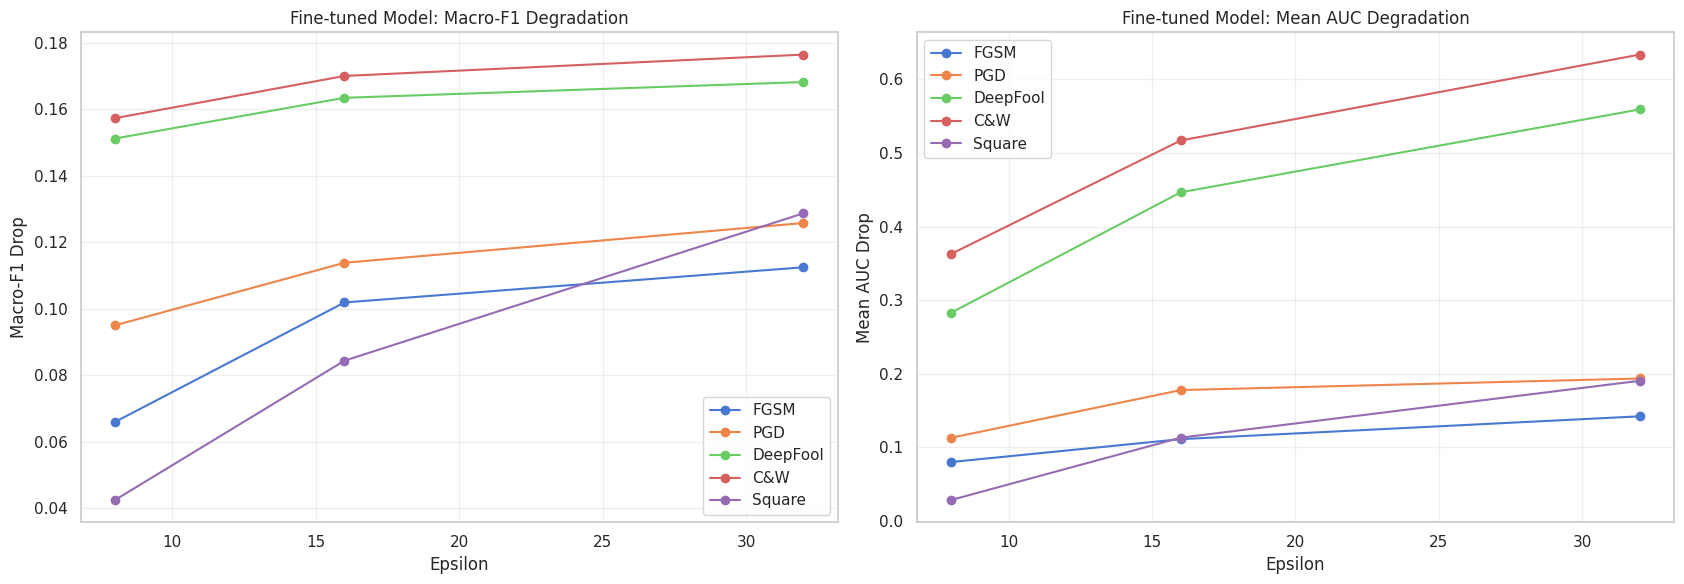

Saved extended_attack_degradation.png


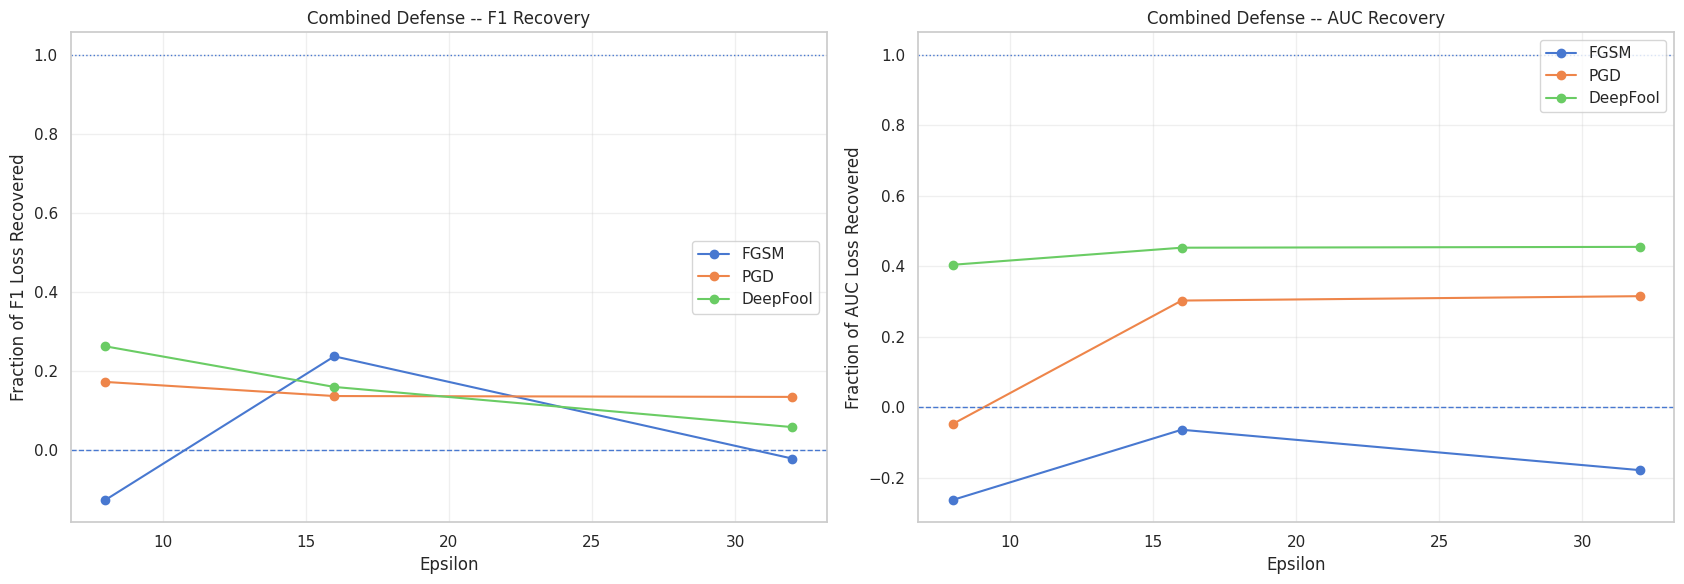

Saved defense_recovery.png


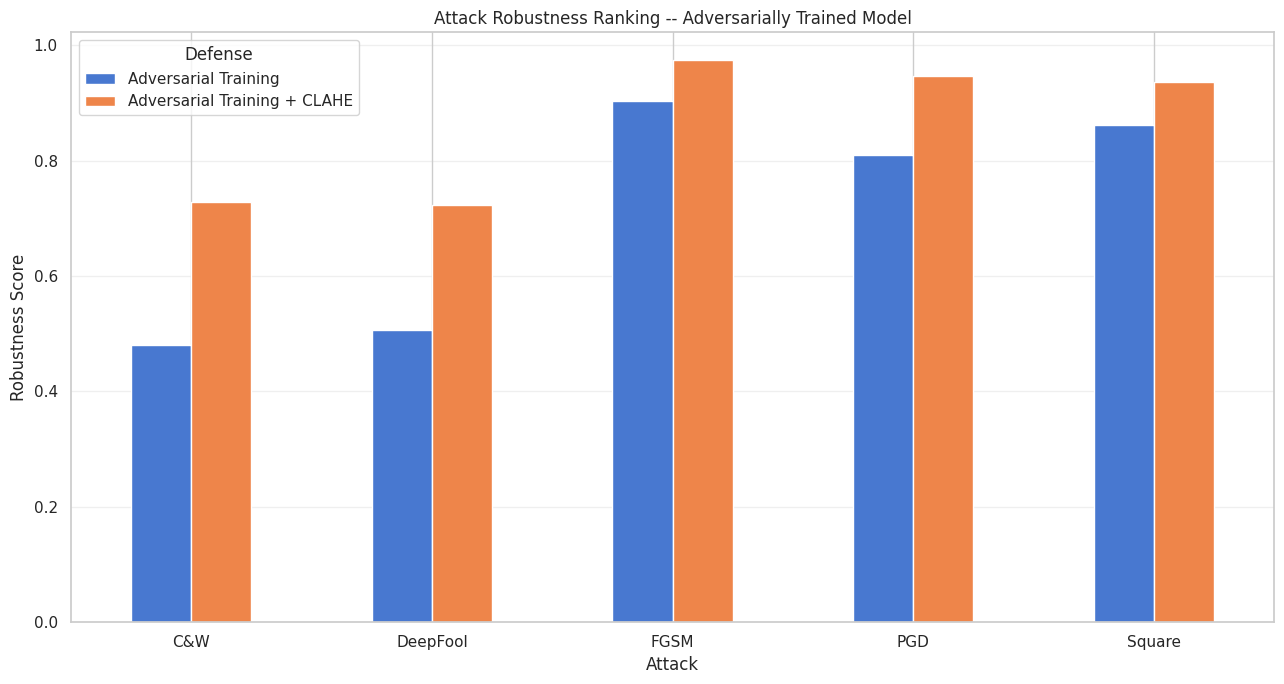

Saved attack_robustness_ranking.png


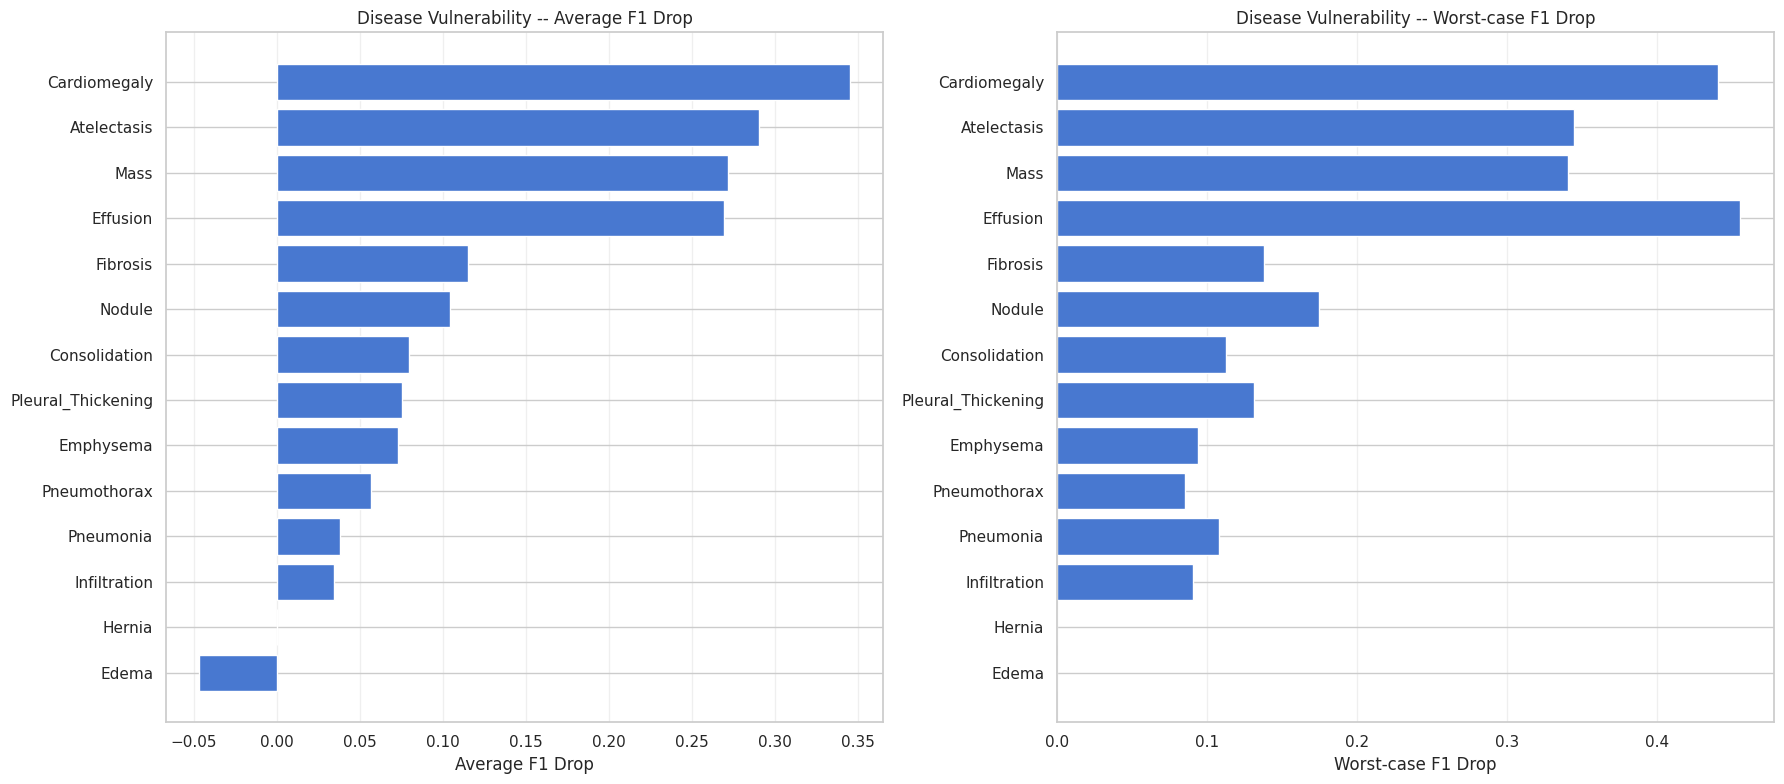

Saved per_class_vulnerability.png


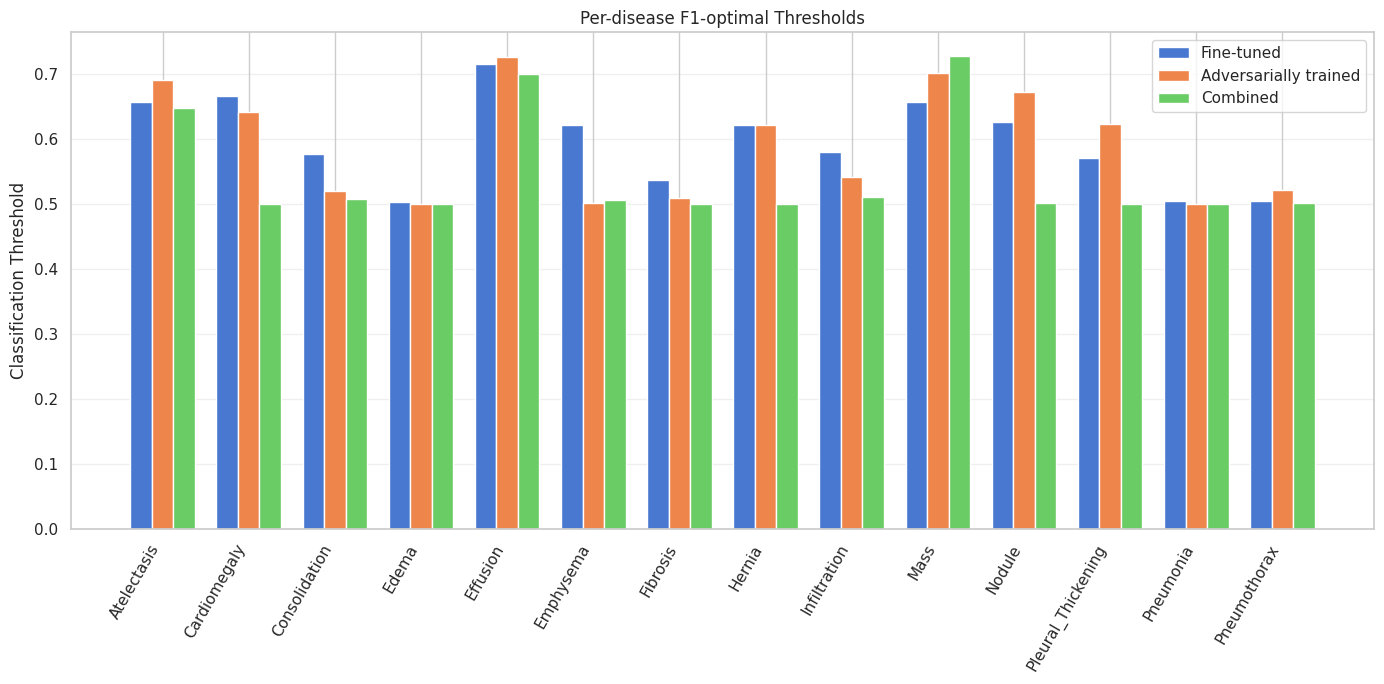

Saved threshold_analysis.png

EXTENDED ANALYSIS -- KEY RESULTS

Attack ranking:
                Model                      Defense   Attack  RobustnessScore
Adversarially trained Adversarial Training + CLAHE     FGSM         0.973885
Adversarially trained Adversarial Training + CLAHE      PGD         0.946936
Adversarially trained Adversarial Training + CLAHE   Square         0.936209
Adversarially trained         Adversarial Training     FGSM         0.903992
Adversarially trained         Adversarial Training   Square         0.862619
Adversarially trained         Adversarial Training      PGD         0.809793
Adversarially trained Adversarial Training + CLAHE      C&W         0.728419
Adversarially trained Adversarial Training + CLAHE DeepFool         0.723706
Adversarially trained         Adversarial Training DeepFool         0.505910
Adversarially trained         Adversarial Training      C&W         0.480850
           Fine-tuned                        CLAHE     FGSM         0.877

In [54]:
# ================================================================
# NEW CELL: Extended robustness / defense / vulnerability analysis
# ================================================================
# This cell uses metrics and probability arrays ALREADY computed above.
# It does NOT rerun inference or attacks.
# New outputs:
#   extended_attack_metrics.csv
#   attack_degradation_analysis.csv
#   defense_comparison.csv
#   attack_ranking.csv
#   per_class_vulnerability.csv
#   threshold_analysis.csv
#   training_analysis.csv                 (when training history exists)
#   extended_attack_degradation.png
#   defense_recovery.png
#   attack_robustness_ranking.png
#   per_class_vulnerability.png
#   threshold_analysis.png
#   training_generalization.png           (when training history exists)
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

OUTPUT_PREFIX = "extended_"
# ------------------------------------------------
# 1. Helper: calculate all metrics from stored data
# ------------------------------------------------
def _aggregate_metrics(probs, labels, threshold):
    _, agg = compute_full_metrics(
        probs,
        labels,
        dataset.pathologies,
        threshold=threshold)
    return agg
def _per_class_metrics(probs, labels, threshold):
    per_class, _ = compute_full_metrics(
        probs,
        labels,
        dataset.pathologies,
        threshold=threshold)
    return per_class
def _metric_change(attacked, clean):
    return {
        "delta_micro_f1": attacked["MicroF1"] - clean["MicroF1"],
        "delta_macro_f1": attacked["MacroF1"] - clean["MacroF1"],
        "delta_mean_auc": attacked["MeanAUC"] - clean["MeanAUC"],
        "delta_hamming": attacked["HammingLoss"] - clean["HammingLoss"],
        # Positive values mean performance degradation.
        "macro_f1_drop": clean["MacroF1"] - attacked["MacroF1"],
        "mean_auc_drop": clean["MeanAUC"] - attacked["MeanAUC"],
        "hamming_increase": attacked["HammingLoss"] - clean["HammingLoss"],
        # Fraction of clean performance retained.
        "macro_f1_retention": attacked["MacroF1"] / max(clean["MacroF1"], 1e-8),
        "auc_retention": attacked["MeanAUC"] / max(clean["MeanAUC"], 1e-8),
    }

# ------------------------------------------------
# 2. Build one unified representation of everything
# ------------------------------------------------
# Every entry:
#   name
#   model
#   defense
#   attack
#   epsilon
#   probs
#   labels
#   threshold
# C&W and Square explicitly use their 300-image subset.

evaluation_records = []
def add_record(
    setting,
    model_name,
    defense_name,
    attack_name,
    epsilon,
    probs,
    labels, threshold, sample_scope
):
    agg = _aggregate_metrics(probs, labels, threshold)
    evaluation_records.append({
        "Setting": setting,
        "Model": model_name,
        "Defense": defense_name,
        "Attack": attack_name,
        "Epsilon": epsilon,
        "SampleScope": sample_scope,
        "N": len(labels),
        "MicroPrecision": agg["micro_precision"],
        "MicroRecall": agg["micro_recall"],
        "MicroF1": agg["micro_f1"],
        "MacroPrecision": agg["macro_precision"],
        "MacroRecall": agg["macro_recall"],
        "MacroF1": agg["macro_f1"],
        "MeanAUC": agg["mean_auc"],
        "HammingLoss": agg["hamming_loss"],
        # Keep references for later analysis.
        "_probs": probs,
        "_labels": labels,
        "_threshold": threshold
    })

# ================================================================
# Fine-tuned model
# ================================================================

add_record(
    "Fine-tuned -- Clean",
    "Fine-tuned",
    "None",
    "Clean",
    0,
    ft_probs,
    ft_labels,
    per_class_thresh,
    "Full test"
)

for attack_name, prob_dict, labels in [
    ("FGSM", fgsm_all_probs, fgsm_all_labels),
    ("PGD", pgd_all_probs, pgd_all_labels),
    ("DeepFool", deepfool_all_probs, deepfool_all_labels),
]:
    for eps in epsilons:
        add_record(
            f"Fine-tuned vs {attack_name} eps={int(eps)}",
            "Fine-tuned",
            "None",
            attack_name,
            eps,
            prob_dict[eps],
            labels,
            per_class_thresh,
            "Full test"
        )


# C&W / Square -- matched subset clean baseline
add_record(
    "Fine-tuned -- Clean (C&W/Square subset)",
    "Fine-tuned",
    "None",
    "Clean",
    0,
    subset_clean_probs,
    subset_clean_labels,
    per_class_thresh,
    "300-image attack subset"
)

for attack_name, prob_dict, labels in [
    ("C&W", cw_all_probs, cw_all_labels),
    ("Square", sq_all_probs, sq_all_labels),
]:
    for eps in epsilons:
        add_record(
            f"Fine-tuned vs {attack_name} eps={int(eps)}",
            "Fine-tuned",
            "None",
            attack_name,
            eps,
            prob_dict[eps],
            labels,
            per_class_thresh,
            "300-image attack subset"
        )


# ================================================================
# CLAHE
# ================================================================

add_record(
    "CLAHE -- Clean",
    "Fine-tuned",
    "CLAHE",
    "Clean",
    0,
    clahe_clean_probs,
    clahe_clean_labels,
    per_class_thresh,
    "Full test"
)

for attack_name, prob_dict, labels in [
    ("FGSM", clahe_fgsm_probs, clahe_fgsm_labels),
    ("PGD", clahe_pgd_probs, clahe_pgd_labels),
    ("DeepFool", clahe_df_probs, clahe_df_labels),
]:
    for eps in epsilons:
        add_record(
            f"CLAHE vs {attack_name} eps={int(eps)}",
            "Fine-tuned",
            "CLAHE",
            attack_name,
            eps,
            prob_dict[eps],
            labels,
            per_class_thresh,
            "Full test"
        )

add_record(
    "CLAHE -- Clean (C&W/Square subset)",
    "Fine-tuned",
    "CLAHE",
    "Clean",
    0,
    subset_clean_probs,       # matched image subset
    subset_clean_labels,
    per_class_thresh,
    "300-image attack subset"
)

for attack_name, prob_dict, labels in [
    ("C&W", clahe_cw_probs, clahe_cw_labels),
    ("Square", clahe_sq_probs, clahe_sq_labels),
]:
    for eps in epsilons:
        add_record(
            f"CLAHE vs {attack_name} eps={int(eps)}",
            "Fine-tuned",
            "CLAHE",
            attack_name,
            eps,
            prob_dict[eps],
            labels,
            per_class_thresh,
            "300-image attack subset"
        )


# ================================================================
# Robust / adversarially trained model
# ================================================================

add_record(
    "Robust -- Clean",
    "Adversarially trained",
    "Adversarial Training",
    "Clean",
    0,
    robust_clean_probs,
    robust_clean_labels,
    per_class_thresh_robust,
    "Full test"
)

for attack_name, prob_dict, labels in [
    ("FGSM", robust_fgsm_probs, robust_fgsm_labels),
    ("PGD", robust_pgd_probs, robust_pgd_labels),
    ("DeepFool", robust_df_probs, robust_df_labels),
]:
    for eps in epsilons:
        add_record(
            f"Robust vs {attack_name} eps={int(eps)}",
            "Adversarially trained",
            "Adversarial Training",
            attack_name,
            eps,
            prob_dict[eps],
            labels,
            per_class_thresh_robust,
            "Full test"
        )

add_record(
    "Robust -- Clean (C&W/Square subset)",
    "Adversarially trained",
    "Adversarial Training",
    "Clean",
    0,
    robust_clean_probs[:len(robust_cw_labels)],
    robust_clean_labels[:len(robust_cw_labels)],
    per_class_thresh_robust,
    "300-image attack subset"
)

for attack_name, prob_dict, labels in [
    ("C&W", robust_cw_probs, robust_cw_labels),
    ("Square", robust_sq_probs, robust_sq_labels),
]:
    for eps in epsilons:
        add_record(
            f"Robust vs {attack_name} eps={int(eps)}",
            "Adversarially trained",
            "Adversarial Training",
            attack_name,
            eps,
            prob_dict[eps],
            labels,
            per_class_thresh_robust,
            "300-image attack subset"
        )


# ================================================================
# Combined = adversarial training + CLAHE
# ================================================================

add_record(
    "Combined -- Clean",
    "Adversarially trained",
    "Adversarial Training + CLAHE",
    "Clean",
    0,
    combined_clean_probs,
    combined_clean_labels,
    per_class_thresh_combined,
    "Full test"
)

for attack_name, prob_dict, labels in [
    ("FGSM", combined_fgsm_probs, combined_fgsm_labels),
    ("PGD", combined_pgd_probs, combined_pgd_labels),
    ("DeepFool", combined_df_probs, combined_df_labels),
]:
    for eps in epsilons:
        add_record(
            f"Combined vs {attack_name} eps={int(eps)}",
            "Adversarially trained",
            "Adversarial Training + CLAHE",
            attack_name,
            eps,
            prob_dict[eps],
            labels,
            per_class_thresh_combined,
            "Full test"
        )

add_record(
    "Combined -- Clean (C&W/Square subset)",
    "Adversarially trained",
    "Adversarial Training + CLAHE",
    "Clean",
    0,
    combined_clean_probs[:len(combined_cw_labels)],
    combined_clean_labels[:len(combined_cw_labels)],
    per_class_thresh_combined,
    "300-image attack subset"
)

for attack_name, prob_dict, labels in [
    ("C&W", combined_cw_probs, combined_cw_labels),
    ("Square", combined_sq_probs, combined_sq_labels),
]:
    for eps in epsilons:
        add_record(
            f"Combined vs {attack_name} eps={int(eps)}",
            "Adversarially trained",
            "Adversarial Training + CLAHE",
            attack_name,
            eps,
            prob_dict[eps],
            labels,
            per_class_thresh_combined,
            "300-image attack subset"
        )


# ------------------------------------------------
# 3. Save the complete extended metric table
# ------------------------------------------------

records_for_csv = []

for r in evaluation_records:
    row = {k: v for k, v in r.items() if not k.startswith("_")}
    records_for_csv.append(row)

extended_metrics_df = pd.DataFrame(records_for_csv)

extended_metrics_df.to_csv(
    "extended_attack_metrics.csv",
    index=False
)

print("Saved extended_attack_metrics.csv")


# ================================================================
# 4. Attack degradation relative to the CORRECT clean baseline
# ================================================================

degradation_rows = []


def find_clean_record(model_name, defense_name, sample_scope):
    matches = [
        r for r in evaluation_records
        if r["Model"] == model_name
        and r["Defense"] == defense_name
        and r["Attack"] == "Clean"
        and r["SampleScope"] == sample_scope
    ]

    if not matches:
        return None

    return matches[0]


for r in evaluation_records:

    if r["Attack"] == "Clean":
        continue

    clean = find_clean_record(
        r["Model"],
        r["Defense"],
        r["SampleScope"]
    )

    if clean is None:
        continue

    changes = _metric_change(r, clean)

    degradation_rows.append({
        "Model": r["Model"],
        "Defense": r["Defense"],
        "Attack": r["Attack"],
        "Epsilon": r["Epsilon"],
        "SampleScope": r["SampleScope"],

        "CleanMacroF1": clean["MacroF1"],
        "AttackMacroF1": r["MacroF1"],
        "MacroF1Drop": changes["macro_f1_drop"],
        "MacroF1Retention": changes["macro_f1_retention"],

        "CleanAUC": clean["MeanAUC"],
        "AttackAUC": r["MeanAUC"],
        "AUCdrop": changes["mean_auc_drop"],
        "AUCRetention": changes["auc_retention"],

        "CleanHamming": clean["HammingLoss"],
        "AttackHamming": r["HammingLoss"],
        "HammingIncrease": changes["hamming_increase"],

        "MicroF1Change": changes["delta_micro_f1"]
    })


degradation_df = pd.DataFrame(degradation_rows)

degradation_df.to_csv(
    "attack_degradation_analysis.csv",
    index=False
)

print("Saved attack_degradation_analysis.csv")


# ================================================================
# 5. Defense recovery analysis
# ================================================================
#
# Recovery is:
#
#     (defended_attack - attacked_no_defense)
#     -------------------------------------
#     (clean - attacked_no_defense)
#
# Example:
#
# clean F1 = .80
# attacked F1 = .50
# defended F1 = .65
#
# recovery = (.65-.50)/(.80-.50) = 0.50
#
# So the defense recovered 50% of the lost F1.
# ================================================================

def get_eval(model_name, defense, attack, eps, scope):
    for r in evaluation_records:
        if (
            r["Model"] == model_name
            and r["Defense"] == defense
            and r["Attack"] == attack
            and r["Epsilon"] == eps
            and r["SampleScope"] == scope
        ):
            return r
    return None


def recovery(defended, attacked, clean, metric):
    if metric == "MacroF1":
        lost = clean["MacroF1"] - attacked["MacroF1"]
        recovered = defended["MacroF1"] - attacked["MacroF1"]
    elif metric == "MeanAUC":
        lost = clean["MeanAUC"] - attacked["MeanAUC"]
        recovered = defended["MeanAUC"] - attacked["MeanAUC"]
    elif metric == "HammingLoss":
        # For Hamming, lower is better.
        lost = attacked["HammingLoss"] - clean["HammingLoss"]
        recovered = attacked["HammingLoss"] - defended["HammingLoss"]
    else:
        return np.nan

    if abs(lost) < 1e-10:
        return np.nan

    return recovered / lost


def add_defense_comparison(
    attack,
    eps,
    scope
):
    ft = get_eval("Fine-tuned", "None", attack, eps, scope)
    clahe = get_eval("Fine-tuned", "CLAHE", attack, eps, scope)

    robust = get_eval(
        "Adversarially trained",
        "Adversarial Training",
        attack,
        eps,
        scope
    )

    combined = get_eval(
        "Adversarially trained",
        "Adversarial Training + CLAHE",
        attack,
        eps,
        scope
    )

    # For robustness comparisons, the clean baseline is the corresponding
    # defense's clean performance.
    ft_clean = get_eval(
        "Fine-tuned",
        "None",
        "Clean",
        0,
        scope
    )

    clahe_clean = get_eval(
        "Fine-tuned",
        "CLAHE",
        "Clean",
        0,
        scope
    )

    robust_clean = get_eval(
        "Adversarially trained",
        "Adversarial Training",
        "Clean",
        0,
        scope
    )

    combined_clean = get_eval(
        "Adversarially trained",
        "Adversarial Training + CLAHE",
        "Clean",
        0,
        scope
    )

    if ft is None:
        return

    row = {
        "Attack": attack,
        "Epsilon": eps,
        "SampleScope": scope,

        "FT_MacroF1": ft["MacroF1"],
        "CLAHE_MacroF1": clahe["MacroF1"] if clahe else np.nan,
        "Robust_MacroF1": robust["MacroF1"] if robust else np.nan,
        "Combined_MacroF1": combined["MacroF1"] if combined else np.nan,

        "FT_AUC": ft["MeanAUC"],
        "CLAHE_AUC": clahe["MeanAUC"] if clahe else np.nan,
        "Robust_AUC": robust["MeanAUC"] if robust else np.nan,
        "Combined_AUC": combined["MeanAUC"] if combined else np.nan,

        "FT_Hamming": ft["HammingLoss"],
        "CLAHE_Hamming": clahe["HammingLoss"] if clahe else np.nan,
        "Robust_Hamming": robust["HammingLoss"] if robust else np.nan,
        "Combined_Hamming": combined["HammingLoss"] if combined else np.nan,
    }

    # ------------------------------------------------------------
    # Direct defense gains relative to the undefended FT model
    # ------------------------------------------------------------

    if clahe is not None:
        row["CLAHE_F1_Gain_vs_FT"] = (
            clahe["MacroF1"] - ft["MacroF1"]
        )
        row["CLAHE_AUC_Gain_vs_FT"] = (
            clahe["MeanAUC"] - ft["MeanAUC"]
        )

    if robust is not None:
        row["Robust_F1_Gain_vs_FT"] = (
            robust["MacroF1"] - ft["MacroF1"]
        )
        row["Robust_AUC_Gain_vs_FT"] = (
            robust["MeanAUC"] - ft["MeanAUC"]
        )

    if combined is not None:
        row["Combined_F1_Gain_vs_FT"] = (
            combined["MacroF1"] - ft["MacroF1"]
        )
        row["Combined_AUC_Gain_vs_FT"] = (
            combined["MeanAUC"] - ft["MeanAUC"]
        )

    # ------------------------------------------------------------
    # Percentage of lost performance recovered
    # ------------------------------------------------------------

    if clahe is not None and ft_clean is not None:
        row["CLAHE_F1_Recovery"] = recovery(
            clahe, ft, ft_clean, "MacroF1"
        )
        row["CLAHE_AUC_Recovery"] = recovery(
            clahe, ft, ft_clean, "MeanAUC"
        )

    if robust is not None and robust_clean is not None:
        row["Robust_F1_Recovery"] = recovery(
            robust, ft, ft_clean, "MacroF1"
        )
        row["Robust_AUC_Recovery"] = recovery(
            robust, ft, ft_clean, "MeanAUC"
        )

    if combined is not None and combined_clean is not None:
        row["Combined_F1_Recovery"] = recovery(
            combined, ft, ft_clean, "MacroF1"
        )
        row["Combined_AUC_Recovery"] = recovery(
            combined, ft, ft_clean, "MeanAUC"
        )

    return row


defense_rows = []

for attack in epsilons and ["FGSM", "PGD", "DeepFool", "C&W", "Square"]:
    scope = (
        "300-image attack subset"
        if attack in ["C&W", "Square"]
        else "Full test"
    )

    for eps in epsilons:
        row = add_defense_comparison(
            attack,
            eps,
            scope
        )

        if row is not None:
            defense_rows.append(row)


defense_df = pd.DataFrame(defense_rows)

defense_df.to_csv(
    "defense_comparison.csv",
    index=False
)

print("Saved defense_comparison.csv")


# ================================================================
# 6. Attack ranking / robustness score
# ================================================================
#
# A single number is useful for answering:
#
# "Which attack is most damaging to this model?"
#
# We use:
#
#   F1 degradation
#   AUC degradation
#   Hamming increase
#
# after normalizing by the clean value.
#
# Larger RobustnessScore = better robustness.
# ================================================================

ranking_rows = []

for model_name, defense_name in [
    ("Fine-tuned", "None"),
    ("Fine-tuned", "CLAHE"),
    ("Adversarially trained", "Adversarial Training"),
    ("Adversarially trained", "Adversarial Training + CLAHE"),
]:

    for attack in ["FGSM", "PGD", "DeepFool", "C&W", "Square"]:

        scope = (
            "300-image attack subset"
            if attack in ["C&W", "Square"]
            else "Full test"
        )

        clean = get_eval(
            model_name,
            defense_name,
            "Clean",
            0,
            scope
        )

        if clean is None:
            continue

        attack_rows = [
            r for r in evaluation_records
            if r["Model"] == model_name
            and r["Defense"] == defense_name
            and r["Attack"] == attack
            and r["SampleScope"] == scope
        ]

        if not attack_rows:
            continue

        f1_drops = []
        auc_drops = []
        ham_increases = []

        for r in attack_rows:
            f1_drops.append(
                (clean["MacroF1"] - r["MacroF1"])
                / max(clean["MacroF1"], 1e-8)
            )

            auc_drops.append(
                (clean["MeanAUC"] - r["MeanAUC"])
                / max(clean["MeanAUC"], 1e-8)
            )

            ham_increases.append(
                r["HammingLoss"] - clean["HammingLoss"]
            )

        avg_f1_drop = np.mean(f1_drops)
        avg_auc_drop = np.mean(auc_drops)
        avg_ham_increase = np.mean(ham_increases)

        # Convert to a "higher is better" score.
        # The clipping prevents an unusually good adversarial result from
        # producing an absurdly large robustness value.
        robustness_score = (
            1.0
            - 0.4 * avg_f1_drop
            - 0.4 * avg_auc_drop
            - 0.2 * avg_ham_increase
        )

        ranking_rows.append({
            "Model": model_name,
            "Defense": defense_name,
            "Attack": attack,
            "AverageRelativeF1Drop": avg_f1_drop,
            "AverageRelativeAUCDrop": avg_auc_drop,
            "AverageHammingIncrease": avg_ham_increase,
            "RobustnessScore": robustness_score
        })


ranking_df = pd.DataFrame(ranking_rows)

ranking_df = ranking_df.sort_values(
    ["Model", "RobustnessScore"],
    ascending=[True, False]
)

ranking_df.to_csv(
    "attack_ranking.csv",
    index=False
)

print("Saved attack_ranking.csv")


# ================================================================
# 7. Attack severity slope + area under robustness curve
# ================================================================

severity_rows = []

for model_name, defense_name in [
    ("Fine-tuned", "None"),
    ("Fine-tuned", "CLAHE"),
    ("Adversarially trained", "Adversarial Training"),
    ("Adversarially trained", "Adversarial Training + CLAHE"),
]:

    for attack in ["FGSM", "PGD", "DeepFool", "C&W", "Square"]:

        scope = (
            "300-image attack subset"
            if attack in ["C&W", "Square"]
            else "Full test"
        )

        clean = get_eval(
            model_name,
            defense_name,
            "Clean",
            0,
            scope
        )

        rows = [
            r for r in evaluation_records
            if r["Model"] == model_name
            and r["Defense"] == defense_name
            and r["Attack"] == attack
            and r["SampleScope"] == scope
        ]

        if clean is None or len(rows) < 2:
            continue

        rows = sorted(rows, key=lambda x: x["Epsilon"])

        eps_arr = np.array([r["Epsilon"] for r in rows], dtype=float)

        f1_ret = np.array([
            r["MacroF1"] / max(clean["MacroF1"], 1e-8)
            for r in rows
        ])

        auc_ret = np.array([
            r["MeanAUC"] / max(clean["MeanAUC"], 1e-8)
            for r in rows
        ])

        # Linear deterioration rate.
        f1_slope = np.polyfit(eps_arr, f1_ret, 1)[0]
        auc_slope = np.polyfit(eps_arr, auc_ret, 1)[0]

        # Area under retention-vs-epsilon curve.
        # Higher = better.
        f1_auc_eps = np.trapz(f1_ret, eps_arr)
        auc_auc_eps = np.trapz(auc_ret, eps_arr)

        # Normalize to [0, 1] approximately by the epsilon range.
        eps_range = max(eps_arr[-1] - eps_arr[0], 1e-8)

        severity_rows.append({
            "Model": model_name,
            "Defense": defense_name,
            "Attack": attack,

            "F1RetentionSlope": f1_slope,
            "AUCRetentionSlope": auc_slope,

            "F1RobustnessAUC": f1_auc_eps / eps_range,
            "AUCRobustnessAUC": auc_auc_eps / eps_range,

            "F1RetentionAtMinEps": f1_ret[0],
            "F1RetentionAtMaxEps": f1_ret[-1],

            "AUCRetentionAtMinEps": auc_ret[0],
            "AUCRetentionAtMaxEps": auc_ret[-1],
        })


severity_df = pd.DataFrame(severity_rows)

severity_df.to_csv(
    "attack_severity_analysis.csv",
    index=False
)

print("Saved attack_severity_analysis.csv")


# ================================================================
# 8. Per-class vulnerability analysis
# ================================================================
#
# This is one of the most useful new analyses.
#
# Instead of only asking:
#
#   "Did Macro-F1 fall?"
#
# we ask:
#
#   "Which disease caused the fall?"
#
# For every disease we calculate:
#
#   clean F1
#   clean AUC
#   average F1 drop across attacks
#   worst F1 drop
#   average AUC drop
#   worst AUC drop
#   most damaging attack
# ================================================================

class_rows = []

# Use the fine-tuned model as the baseline vulnerability analysis.
# The same machinery can compare other defenses if needed.
base_model = "Fine-tuned"
base_defense = "None"

for disease_idx, disease in enumerate(dataset.pathologies):

    # Full-test clean
    clean_pc = _per_class_metrics(
        ft_probs,
        ft_labels,
        per_class_thresh
    )

    if disease not in clean_pc:
        continue

    clean_f1 = clean_pc[disease]["F1"]
    clean_auc = clean_pc[disease]["AUC"]

    attack_f1_drops = []
    attack_auc_drops = []
    attack_names = []

    for attack in ["FGSM", "PGD", "DeepFool"]:

        prob_dict = {
            "FGSM": fgsm_all_probs,
            "PGD": pgd_all_probs,
            "DeepFool": deepfool_all_probs
        }[attack]

        labels = {
            "FGSM": fgsm_all_labels,
            "PGD": pgd_all_labels,
            "DeepFool": deepfool_all_labels
        }[attack]

        for eps in epsilons:

            pc = _per_class_metrics(
                prob_dict[eps],
                labels,
                per_class_thresh
            )

            if disease not in pc:
                continue

            attack_f1_drops.append(
                clean_f1 - pc[disease]["F1"]
            )

            attack_auc_drops.append(
                clean_auc - pc[disease]["AUC"]
            )

            attack_names.append(
                f"{attack} eps={int(eps)}"
            )

    if not attack_f1_drops:
        continue

    attack_f1_drops = np.array(attack_f1_drops)
    attack_auc_drops = np.array(attack_auc_drops)

    worst_idx = int(np.argmax(attack_f1_drops))

    class_rows.append({
        "Disease": disease,

        "CleanF1": clean_f1,
        "CleanAUC": clean_auc,

        "AverageF1Drop": np.mean(attack_f1_drops),
        "WorstF1Drop": np.max(attack_f1_drops),

        "AverageAUCDrop": np.mean(attack_auc_drops),
        "WorstAUCDrop": np.max(attack_auc_drops),

        "MostDamagingAttack": attack_names[worst_idx],

        "F1Robustness":
            1.0 - np.mean(attack_f1_drops) / max(clean_f1, 1e-8),

        "AUC_Robustness":
            1.0 - np.mean(attack_auc_drops) / max(clean_auc, 1e-8),
    })


class_vulnerability_df = pd.DataFrame(class_rows)

class_vulnerability_df = class_vulnerability_df.sort_values(
    "AverageF1Drop",
    ascending=False
)

class_vulnerability_df.to_csv(
    "per_class_vulnerability.csv",
    index=False
)

print("Saved per_class_vulnerability.csv")


# ================================================================
# 9. Threshold analysis
# ================================================================

threshold_rows = []

for disease in dataset.pathologies:

    row = {
        "Disease": disease,
        "FineTunedThreshold":
            per_class_thresh.get(disease, np.nan),
        "RobustThreshold":
            per_class_thresh_robust.get(disease, np.nan),
        "CombinedThreshold":
            per_class_thresh_combined.get(disease, np.nan),
    }

    row["RobustMinusFT"] = (
        row["RobustThreshold"]
        - row["FineTunedThreshold"]
    )

    row["CombinedMinusFT"] = (
        row["CombinedThreshold"]
        - row["FineTunedThreshold"]
    )

    threshold_rows.append(row)


threshold_df = pd.DataFrame(threshold_rows)

threshold_df.to_csv(
    "threshold_analysis.csv",
    index=False
)

print("Saved threshold_analysis.csv")


# ================================================================
# 10. Training/generalization analysis
# ================================================================

if (
    "train_losses" in globals()
    and len(train_losses) > 0
    and "val_losses" in globals()
    and len(val_losses) > 0
):

    n_epochs = min(
        len(train_losses),
        len(val_losses),
        len(train_f1s),
        len(val_f1s)
    )

    train_df = pd.DataFrame({
        "Epoch": np.arange(1, n_epochs + 1),

        "TrainLoss": train_losses[:n_epochs],
        "ValLoss": val_losses[:n_epochs],

        "TrainMacroF1": train_f1s[:n_epochs],
        "ValMacroF1": val_f1s[:n_epochs],
    })

    train_df["LossGap"] = (
        train_df["ValLoss"] - train_df["TrainLoss"]
    )

    train_df["F1Gap"] = (
        train_df["TrainMacroF1"]
        - train_df["ValMacroF1"]
    )

    best_loss_epoch = int(
        train_df.loc[
            train_df["ValLoss"].idxmin(),
            "Epoch"
        ]
    )

    best_f1_epoch = int(
        train_df.loc[
            train_df["ValMacroF1"].idxmax(),
            "Epoch"
        ]
    )

    train_df["BestValLossEpoch"] = best_loss_epoch
    train_df["BestValF1Epoch"] = best_f1_epoch

    train_df.to_csv(
        "training_analysis.csv",
        index=False
    )

    print("Saved training_analysis.csv")

else:
    print(
        "Training arrays are empty because the model was loaded "
        "from checkpoint. Skipping training_analysis.csv."
    )


# ================================================================
# 11. PNG 1 -- Attack degradation
# ================================================================

plot_df = degradation_df.copy()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Fine-tuned only: F1 degradation
for attack in ["FGSM", "PGD", "DeepFool", "C&W", "Square"]:

    sub = plot_df[
        (plot_df["Model"] == "Fine-tuned")
        & (plot_df["Defense"] == "None")
        & (plot_df["Attack"] == attack)
    ]

    if len(sub) == 0:
        continue

    axes[0].plot(
        sub["Epsilon"],
        sub["MacroF1Drop"],
        marker="o",
        label=attack
    )

axes[0].set_xlabel("Epsilon")
axes[0].set_ylabel("Macro-F1 Drop")
axes[0].set_title(
    "Fine-tuned Model: Macro-F1 Degradation"
)
axes[0].grid(alpha=0.3)
axes[0].legend()


# AUC degradation
for attack in ["FGSM", "PGD", "DeepFool", "C&W", "Square"]:

    sub = plot_df[
        (plot_df["Model"] == "Fine-tuned")
        & (plot_df["Defense"] == "None")
        & (plot_df["Attack"] == attack)
    ]

    if len(sub) == 0:
        continue

    axes[1].plot(
        sub["Epsilon"],
        sub["AUCdrop"],
        marker="o",
        label=attack
    )

axes[1].set_xlabel("Epsilon")
axes[1].set_ylabel("Mean AUC Drop")
axes[1].set_title(
    "Fine-tuned Model: Mean AUC Degradation"
)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()

plt.savefig(
    "extended_attack_degradation.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved extended_attack_degradation.png")


# ================================================================
# 12. PNG 2 -- Defense recovery
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

for attack in ["FGSM", "PGD", "DeepFool"]:

    sub = defense_df[
        defense_df["Attack"] == attack
    ]

    if len(sub) == 0:
        continue

    # Combined defense recovery
    axes[0].plot(
        sub["Epsilon"],
        sub["Combined_F1_Recovery"],
        marker="o",
        label=attack
    )

    axes[1].plot(
        sub["Epsilon"],
        sub["Combined_AUC_Recovery"],
        marker="o",
        label=attack
    )

axes[0].axhline(
    0,
    linestyle="--",
    linewidth=1
)

axes[0].axhline(
    1,
    linestyle=":",
    linewidth=1
)

axes[0].set_xlabel("Epsilon")
axes[0].set_ylabel("Fraction of F1 Loss Recovered")
axes[0].set_title(
    "Combined Defense -- F1 Recovery"
)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].axhline(
    0,
    linestyle="--",
    linewidth=1
)

axes[1].axhline(
    1,
    linestyle=":",
    linewidth=1
)

axes[1].set_xlabel("Epsilon")
axes[1].set_ylabel("Fraction of AUC Loss Recovered")
axes[1].set_title(
    "Combined Defense -- AUC Recovery"
)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()

plt.savefig(
    "defense_recovery.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved defense_recovery.png")


# ================================================================
# 13. PNG 3 -- Attack robustness ranking
# ================================================================

ranking_plot = ranking_df[
    ranking_df["Defense"].isin([
        "None",
        "Adversarial Training",
        "Adversarial Training + CLAHE"
    ])
].copy()

# Focus on the adversarially trained model + combined defense.
ranking_plot = ranking_plot[
    ranking_plot["Model"] == "Adversarially trained"
]

if len(ranking_plot) > 0:

    pivot = ranking_plot.pivot(
        index="Attack",
        columns="Defense",
        values="RobustnessScore"
    )

    pivot.plot(
        kind="bar",
        figsize=(13, 7)
    )

    plt.ylabel("Robustness Score")
    plt.xlabel("Attack")
    plt.title(
        "Attack Robustness Ranking -- Adversarially Trained Model"
    )
    plt.grid(alpha=0.3, axis="y")
    plt.xticks(rotation=0)
    plt.legend(title="Defense")

    plt.tight_layout()

    plt.savefig(
        "attack_robustness_ranking.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved attack_robustness_ranking.png")


# ================================================================
# 14. PNG 4 -- Disease vulnerability
# ================================================================

if len(class_vulnerability_df) > 0:

    top_n = min(14, len(class_vulnerability_df))
    vuln_plot = class_vulnerability_df.head(top_n)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(18, 8)
    )

    # Average F1 degradation
    axes[0].barh(
        vuln_plot["Disease"][::-1],
        vuln_plot["AverageF1Drop"][::-1]
    )

    axes[0].set_xlabel("Average F1 Drop")
    axes[0].set_title(
        "Disease Vulnerability -- Average F1 Drop"
    )
    axes[0].grid(alpha=0.3, axis="x")

    # Worst F1 degradation
    axes[1].barh(
        vuln_plot["Disease"][::-1],
        vuln_plot["WorstF1Drop"][::-1]
    )

    axes[1].set_xlabel("Worst-case F1 Drop")
    axes[1].set_title(
        "Disease Vulnerability -- Worst-case F1 Drop"
    )
    axes[1].grid(alpha=0.3, axis="x")

    plt.tight_layout()

    plt.savefig(
        "per_class_vulnerability.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved per_class_vulnerability.png")


# ================================================================
# 15. PNG 5 -- Threshold analysis
# ================================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)

x = np.arange(len(threshold_df))
width = 0.25

ax.bar(
    x - width,
    threshold_df["FineTunedThreshold"],
    width,
    label="Fine-tuned"
)

ax.bar(
    x,
    threshold_df["RobustThreshold"],
    width,
    label="Adversarially trained"
)

ax.bar(
    x + width,
    threshold_df["CombinedThreshold"],
    width,
    label="Combined"
)

ax.set_xticks(x)
ax.set_xticklabels(
    threshold_df["Disease"],
    rotation=60,
    ha="right"
)

ax.set_ylabel("Classification Threshold")
ax.set_title(
    "Per-disease F1-optimal Thresholds"
)

ax.grid(alpha=0.3, axis="y")
ax.legend()

plt.tight_layout()

plt.savefig(
    "threshold_analysis.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved threshold_analysis.png")


# ================================================================
# 16. PNG 6 -- Training/generalization analysis
# ================================================================

if (
    "train_df" in globals()
    and len(train_df) > 0
):

    fig, axes = plt.subplots(
        1, 2,
        figsize=(16, 6)
    )

    axes[0].plot(
        train_df["Epoch"],
        train_df["TrainLoss"],
        marker="o",
        label="Train Loss"
    )

    axes[0].plot(
        train_df["Epoch"],
        train_df["ValLoss"],
        marker="o",
        label="Validation Loss"
    )

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("BCE Loss")
    axes[0].set_title(
        "Training vs Validation Loss"
    )

    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(
        train_df["Epoch"],
        train_df["TrainMacroF1"],
        marker="o",
        label="Train Macro-F1"
    )

    axes[1].plot(
        train_df["Epoch"],
        train_df["ValMacroF1"],
        marker="o",
        label="Validation Macro-F1"
    )

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Macro-F1")
    axes[1].set_title(
        "Training vs Validation Macro-F1"
    )

    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()

    plt.savefig(
        "training_generalization.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved training_generalization.png")


# ================================================================
# 17. Print the most interesting conclusions directly
# ================================================================

print("\n" + "=" * 80)
print("EXTENDED ANALYSIS -- KEY RESULTS")
print("=" * 80)

if len(ranking_df) > 0:
    print("\nAttack ranking:")
    print(
        ranking_df[
            [
                "Model",
                "Defense",
                "Attack",
                "RobustnessScore"
            ]
        ].to_string(index=False)
    )

if len(class_vulnerability_df) > 0:
    print("\nMost vulnerable diseases by average F1 degradation:")
    print(
        class_vulnerability_df[
            [
                "Disease",
                "CleanF1",
                "AverageF1Drop",
                "WorstF1Drop",
                "MostDamagingAttack"
            ]
        ].head(10).to_string(index=False)
    )

print("\nFiles generated:")
print("  extended_attack_metrics.csv")
print("  attack_degradation_analysis.csv")
print("  defense_comparison.csv")
print("  attack_ranking.csv")
print("  attack_severity_analysis.csv")
print("  per_class_vulnerability.csv")
print("  threshold_analysis.csv")

if "train_df" in globals():
    print("  training_analysis.csv")

print("  extended_attack_degradation.png")
print("  defense_recovery.png")
print("  attack_robustness_ranking.png")
print("  per_class_vulnerability.png")
print("  threshold_analysis.png")

if "train_df" in globals():
    print("  training_generalization.png")

print("=" * 80)

In [36]:
# Cell B3b: Precompute attacked images for a fixed pool of dataset images.
# Checks /home/gradio_assets first -- if a cache exists, loads it instead of
# rebuilding, and doesn't touch test_ds/dataset at all in that path.

GRADIO_ASSETS_DIR = "/home/gradio_assets"
os.makedirs(GRADIO_ASSETS_DIR, exist_ok=True)
DEMO_CACHE_PATH = os.path.join(GRADIO_ASSETS_DIR, "demo_cache.pt")

DEMO_N_IMAGES  = 40  
DEMO_EPSILONS  = [8.0, 16.0, 32.0]
multilabel_attacks = (LinfSquareAttack, MultiLabelDeepFool, MultiLabelCW)

if os.path.exists(DEMO_CACHE_PATH):
    print(f"Found cached demo assets at {DEMO_CACHE_PATH} -- loading instead of recomputing.")
    bundle = torch.load(DEMO_CACHE_PATH, map_location=device, weights_only=False)

    demo_images       = bundle["demo_images"].to(device)
    demo_labels       = bundle["demo_labels"].to(device)
    demo_class_labels = bundle["demo_class_labels"].to(device)
    attack_cache_ft = {name: {eps: t.to(device) for eps, t in d.items()}
                        for name, d in bundle["attack_cache_ft"].items()}
    attack_cache_robust = {name: {eps: t.to(device) for eps, t in d.items()}
                            for name, d in bundle["attack_cache_robust"].items()}
    DEMO_N_IMAGES = bundle["DEMO_N_IMAGES"]
    DEMO_EPSILONS = bundle["DEMO_EPSILONS"]
    pathologies_cached      = bundle["pathologies"]
    per_class_thresh_cached = bundle["per_class_thresh"]

    # Fall back to cached metadata if the full dataset wasn't built this run
    # (e.g. running locally without re-downloading NIH data).
    if "dataset" not in globals():
        class _DatasetStub:
            pathologies = pathologies_cached
        dataset = _DatasetStub()
    if "per_class_thresh" not in globals():
        per_class_thresh = per_class_thresh_cached

    model_ft = xrv.models.DenseNet(weights="densenet121-res224-nih").to(device)
    model_ft.load_state_dict(torch.load(best_model_path, map_location=device))
    model_ft.eval()

    model_robust = xrv.models.DenseNet(weights="densenet121-res224-nih").to(device)
    model_robust.load_state_dict(torch.load(robust_model_path, map_location=device))
    model_robust.eval()

    fmodel_ft     = fb.PyTorchModel(model_ft, bounds=(-1024, 1024))
    fmodel_robust = fb.PyTorchModel(model_robust, bounds=(-1024, 1024))

    # Attack objects are cheap Python objects (no crafted tensors to cache) --
    # rebuild them so DEMO_ATTACKS exists for the dropdown/labels in Cell 43.
    demo_deepfool = MultiLabelDeepFool(max_steps=20, step_frac=0.15, thresholds=per_class_thresh, pathology_names=dataset.pathologies)
    demo_cw       = MultiLabelCW(steps=40, lr=0.08, thresholds=per_class_thresh, pathology_names=dataset.pathologies)
    demo_square   = LinfSquareAttack(queries=100, p_init=0.08)
    fgsm_attack = fgsm_attack if "fgsm_attack" in globals() else fb.attacks.FGSM()
    pgd_attack  = pgd_attack  if "pgd_attack"  in globals() else fb.attacks.LinfPGD(steps=20, abs_stepsize=2.0)
    DEMO_ATTACKS = {"FGSM": fgsm_attack, "PGD": pgd_attack, "DeepFool": demo_deepfool,
                     "C&W": demo_cw, "Square": demo_square}

    print("Demo cache loaded -- attack crafting skipped entirely.")

else:
    print("No cached demo assets found -- building from scratch (one-time cost)...")
    demo_images, demo_labels = [], []
    for i in range(DEMO_N_IMAGES):
        sample = test_ds[i]
        demo_images.append(torch.tensor(sample["img"]))
        demo_labels.append(torch.tensor(sample["lab"]))
    demo_images = torch.stack(demo_images).to(device).float()
    demo_labels = torch.stack(demo_labels).to(device).float()
    demo_class_labels = demo_labels.clone()
    demo_class_labels[torch.isnan(demo_class_labels)] = 0.0
    demo_class_labels[demo_class_labels == -1] = 0.0
    demo_class_labels = demo_class_labels.argmax(dim=1).to(device)

    demo_deepfool = MultiLabelDeepFool(max_steps=20, step_frac=0.15, thresholds=per_class_thresh, pathology_names=dataset.pathologies)
    demo_cw       = MultiLabelCW(steps=40, lr=0.08, thresholds=per_class_thresh, pathology_names=dataset.pathologies)
    demo_square   = LinfSquareAttack(queries=100, p_init=0.08)
    DEMO_ATTACKS = {"FGSM": fgsm_attack, "PGD": pgd_attack, "DeepFool": demo_deepfool,
                     "C&W": demo_cw, "Square": demo_square}

    model_ft = xrv.models.DenseNet(weights="densenet121-res224-nih").to(device)
    model_ft.load_state_dict(torch.load(best_model_path))
    model_ft.eval()

    model_robust = xrv.models.DenseNet(weights="densenet121-res224-nih").to(device)
    model_robust.load_state_dict(torch.load(robust_model_path))
    model_robust.eval()

    fmodel_ft     = fb.PyTorchModel(model_ft, bounds=(-1024, 1024))
    fmodel_robust = fb.PyTorchModel(model_robust, bounds=(-1024, 1024))

    attack_cache_ft, attack_cache_robust = {}, {}
    print("Precomputing attacked images for the demo (one-time cost, all images batched together)...")
    for cache, fmodel_for_cache, tag in [(attack_cache_ft, fmodel_ft, "fine-tuned"),
                                          (attack_cache_robust, fmodel_robust, "robust")]:
        for name, attack_fn in DEMO_ATTACKS.items():
            label_arg = demo_labels if isinstance(attack_fn, multilabel_attacks) else demo_class_labels
            _, clipped, _ = attack_fn(fmodel_for_cache, demo_images, label_arg, epsilons=DEMO_EPSILONS)
            cache[name] = {eps: clipped[j].detach() for j, eps in enumerate(DEMO_EPSILONS)}
            print(f"  {name} cached against {tag} model.")
    print("Demo cache ready -- Gradio clicks will now be instant.")

    torch.save({
        "demo_images": demo_images.cpu(),
        "demo_labels": demo_labels.cpu(),
        "demo_class_labels": demo_class_labels.cpu(),
        "attack_cache_ft": {n: {e: t.cpu() for e, t in d.items()} for n, d in attack_cache_ft.items()},
        "attack_cache_robust": {n: {e: t.cpu() for e, t in d.items()} for n, d in attack_cache_robust.items()},
        "DEMO_N_IMAGES": DEMO_N_IMAGES,
        "DEMO_EPSILONS": DEMO_EPSILONS,
        "pathologies": list(dataset.pathologies),
        "per_class_thresh": per_class_thresh,
    }, DEMO_CACHE_PATH)
    print(f"Saved demo assets to {DEMO_CACHE_PATH} -- next run will load this instead of rebuilding.")

No cached demo assets found -- building from scratch (one-time cost)...
Precomputing attacked images for the demo (one-time cost, all images batched together)...
  FGSM cached against fine-tuned model.
  PGD cached against fine-tuned model.
  DeepFool cached against fine-tuned model.
  C&W cached against fine-tuned model.
  Square cached against fine-tuned model.
  FGSM cached against robust model.
  PGD cached against robust model.
  DeepFool cached against robust model.
  C&W cached against robust model.
  Square cached against robust model.
Demo cache ready -- Gradio clicks will now be instant.
Saved demo assets to /home/gradio_assets/demo_cache.pt -- next run will load this instead of rebuilding.


In [48]:
# Cell B4 (UPDATED v2): Gradio demo -- thumbnail gallery picker + amplified diff view
import gradio as gr
from PIL import Image

# model_ft / model_robust / fmodel_ft / fmodel_robust are already loaded in the
# cache-building cell above (moved there so the attack cache could be built
# against the correct model -- see the BUGFIX note there).

def to_display(tensor):
    img = tensor.detach().cpu().numpy()[0, 0]
    img = ((img + 1024) / 2048 * 255).clip(0, 255).astype(np.uint8)
    return Image.fromarray(img)

def to_diff_display(attacked_tensor, original_tensor, amplify=10.0):
    # Amplified |attacked - original|, contrast-stretched, so the (normally
    # invisible) perturbation becomes visible. Pure black = zero difference.
    diff = (attacked_tensor - original_tensor).detach().cpu().numpy()[0, 0]
    diff = np.abs(diff) * amplify
    diff = (diff / 2048.0 * 255).clip(0, 255).astype(np.uint8)
    return Image.fromarray(diff)

def predict_probs_tensor(img_tensor, use_model):
    with torch.no_grad():
        return torch.sigmoid(align_logits(use_model(img_tensor)))[0]

# Thumbnail gallery for picking the source image -- built once from the
# cached demo pool, so it loads instantly.
gallery_items = []
for i in range(DEMO_N_IMAGES):
    thumb = to_display(demo_images[i:i+1])
    true_names = ", ".join([dataset.pathologies[k] for k, v in enumerate(demo_labels[i].cpu().numpy()) if v == 1]) or "Normal"
    gallery_items.append((thumb, f"#{i}: {true_names}"))

def run_pipeline(evt: gr.SelectData, attack_name, eps, defense_name):
    img_index = evt.index  # which gallery thumbnail was clicked

    true_label_vec = demo_labels[img_index:img_index+1][0]
    original_tensor = demo_images[img_index:img_index+1]

    use_robust_model = defense_name in ("Adversarial Training", "Both (CLAHE + Adversarial Training)")
    use_clahe        = defense_name in ("CLAHE", "Both (CLAHE + Adversarial Training)")
    eval_model = model_robust if use_robust_model else model_ft

    # BUGFIX: pick the attack cache that was actually crafted white-box against
    # `eval_model` -- CLAHE-only/"None" use the attack crafted against model_ft,
    # Adversarial-Training/"Both" use the one crafted against model_robust. This
    # also matches the convention used everywhere else in the notebook (Level 1
    # CLAHE is evaluated against fine-tuned-model attacks, Level 2/Combined
    # against robust-model attacks). Originally there was only one shared
    # `attack_cache`, always crafted against whatever `model` happened to be at
    # cache-build time (the robust model, in this notebook's run order) -- so
    # "Defense: None" was silently showing a transferred attack, not a true
    # white-box one.
    attack_cache = attack_cache_robust if use_robust_model else attack_cache_ft
    attacked_tensor = attack_cache[attack_name][eps][img_index:img_index+1]
    defended_tensor = apply_clahe_batch(attacked_tensor) if use_clahe else attacked_tensor

    # Original/Attacked/Defended are now all evaluated through the SAME model
    # (eval_model) so the three panels form one consistent white-box story for
    # whichever defense is selected, instead of mixing in model_ft regardless.
    orig_probs     = predict_probs_tensor(original_tensor, eval_model)
    attacked_probs = predict_probs_tensor(attacked_tensor, eval_model)
    defended_probs = predict_probs_tensor(defended_tensor, eval_model)

    orig_correct, orig_loss         = per_image_metrics(orig_probs,     true_label_vec, per_class_thresh, dataset.pathologies)
    attacked_correct, attacked_loss = per_image_metrics(attacked_probs, true_label_vec, per_class_thresh, dataset.pathologies)
    defended_correct, defended_loss = per_image_metrics(defended_probs, true_label_vec, per_class_thresh, dataset.pathologies)

    true_labels_str = ", ".join([dataset.pathologies[i] for i, v in enumerate(true_label_vec.cpu().numpy()) if v == 1]) or "Normal"
    top_orig     = dataset.pathologies[orig_probs.argmax().item()]
    top_attacked = dataset.pathologies[attacked_probs.argmax().item()]
    top_defended = dataset.pathologies[defended_probs.argmax().item()]

    # Pixel-level stats -- proves the perturbation is small/imperceptible
    # even though the prediction changed.
    max_pixel_change = (attacked_tensor - original_tensor).abs().max().item()
    mean_pixel_change = (attacked_tensor - original_tensor).abs().mean().item()

    metrics_md = (
        "| Stage | Top prediction | Confidence | Correct labels (/14) | Multi-label loss |\n"
        "|---|---|---|---|---|\n"
        f"| Original | {top_orig} | {orig_probs.max().item():.3f} | {orig_correct}/14 | {orig_loss:.3f} |\n"
        f"| Attacked ({attack_name}, eps={eps:.0f}) | {top_attacked} | {attacked_probs.max().item():.3f} | {attacked_correct}/14 | {attacked_loss:.3f} |\n"
        f"| Defended ({defense_name}) | {top_defended} | {defended_probs.max().item():.3f} | {defended_correct}/14 | {defended_loss:.3f} |\n\n"
        f"**True labels:** {true_labels_str}\n\n"
        f"**Pixel change (raw intensity scale, range ~2048):** "
        f"mean={mean_pixel_change:.2f}, max={max_pixel_change:.2f} "
        f"-- imperceptible to the eye, but the 4th panel amplifies it x10 so you can see the pattern.\n\n"
        f"Loss increase from attack: {attacked_loss - orig_loss:+.3f}  |  "
        f"Loss recovered by defense: {attacked_loss - defended_loss:+.3f}  "
        f"(positive = defense helped, moving back toward original loss of {orig_loss:.3f})"
    )
    return (to_display(original_tensor), to_display(attacked_tensor),
            to_diff_display(attacked_tensor, original_tensor), to_display(defended_tensor), metrics_md)

with gr.Blocks(title="Adversarial Robustness Demo -- Chest X-ray Classifier") as demo:
    gr.Markdown("## Adversarial Robustness Demo -- Chest X-ray Classifier\nClick an image below to run it through the pipeline.")

    with gr.Row():
        attack_dd  = gr.Dropdown(list(DEMO_ATTACKS.keys()), label="Attack", value="FGSM")
        eps_dd     = gr.Dropdown(DEMO_EPSILONS, label="Epsilon", value=DEMO_EPSILONS[1])
        defense_dd = gr.Dropdown(
            ["None", "CLAHE", "Adversarial Training", "Both (CLAHE + Adversarial Training)"],
            label="Defense", value="Both (CLAHE + Adversarial Training)"
        )

    gallery = gr.Gallery(value=gallery_items, label="Click a dataset image to run the pipeline",
                          columns=6, height=300, allow_preview=False)

    with gr.Row():
        out_orig     = gr.Image(label="Original")
        out_attacked = gr.Image(label="After attack (looks identical)")
        out_diff     = gr.Image(label="Perturbation, amplified x10 (proves it's not zero)")
        out_defended = gr.Image(label="After defense")

    out_metrics = gr.Markdown(label="Prediction & metric comparison")

    gallery.select(fn=run_pipeline, inputs=[attack_dd, eps_dd, defense_dd],
                    outputs=[out_orig, out_attacked, out_diff, out_defended, out_metrics])

# JARVISLABS CONFIG: the instance's API endpoint exposes port 6006 for
# services like Gradio/Streamlit/FastAPI/Flask out of the box. 7860 (Gradio's
# default) won't be reachable unless you explicitly opened that port when
# creating the instance (e.g. `jl create --http-ports 7860` via the CLI) --
# using 6006 needs no extra instance configuration.
demo.launch(server_name="0.0.0.0", server_port=6006)

* Running on local URL:  http://0.0.0.0:6006
* To create a public link, set `share=True` in `launch()`.
